## Dropout Prediction and Academic Success Prediction

## Problem Statement

The goal of this assignment is to predict whether a student will drop out or not and to predict the academic success of students using machine learning techniques. The dataset used for this task is the "Students Performance Data Set" from the UCI Machine Learning Repository. The dataset contains various attributes related to students' academic performance, including demographic information, study habits, and previous academic records.



### Bias Evaluation

Before training conduct a bias evaluation:  
- Identify potential biases in the dataset (sampling, historical, labeler, measurement, etc.), identify its source.  
- Analyze whether certain groups are over- or under-represented or disproportionately affected, and how you can address it  

### Implement corrective measures to mitigate the identified biases, such as:
- Feature elimination: Remove features that encode sensitive attributes or proxies  
- Reweighting or resampling to balance representation  
- Calibration techniques to adjust predictions across groups  



### Fairness Evaluation

- Evaluate the model's performance overall and across subgroups.  
- Use metrics such as accuracy, precision, recall, F1-score, as appropriate.  
- Use fairness metrics (e.g., statistical parity, equal opportunity), justify them.  

Document these metrics before and after implementing corrective measures.


In [2]:
# load libraries

# Machine Learning and Data Science Libraries
import numpy as np  # to handle arrays
import pandas as pd  # to handle dataframes
import matplotlib.pyplot as plt  # to plot graphs
import seaborn as sns  # to plot graphs
from sklearn.model_selection import train_test_split  # to split data into training and test sets
from sklearn.preprocessing import StandardScaler  # to standardize the data
from sklearn.tree import DecisionTreeClassifier  # Decision Tree model
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier  # Ensemble models
from sklearn.linear_model import LogisticRegression  # Logistic Regression model
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report  # to evaluate the model
from sklearn.model_selection import cross_validate  # to perform cross-validation

Matplotlib is building the font cache; this may take a moment.


In [3]:
from imblearn.over_sampling import SMOTE  # to handle imbalanced data
import warnings  # to ignore warnings
warnings.filterwarnings('ignore')

In [4]:
# Essential libraries
import json # to handle JSON files

In [5]:
# function to convert string keys to integer keys in a dictionary
def str_to_int(str_dict):
    return {int(k): v for k, v in str_dict.items()}

In [6]:
# load mapping JSON files, manually created for data visualization purposes
 
with open('./predict+students+dropout+and+academic+success/mapping/marital_status.json', 'r') as f:
    marital_status_json = str_to_int(json.load(f))

with open('./predict+students+dropout+and+academic+success/mapping/nationality.json', 'r') as f:
    nationality_json = str_to_int(json.load(f))

with open('./predict+students+dropout+and+academic+success/mapping/application_mode.json', 'r') as f:
    application_mode_json = str_to_int(json.load(f))

with open('./predict+students+dropout+and+academic+success/mapping/course.json', 'r') as f:
    course_json = str_to_int(json.load(f))

with open('./predict+students+dropout+and+academic+success/mapping/father_occupations.json', 'r') as f:
    father_occupations_json = str_to_int(json.load(f))

with open('./predict+students+dropout+and+academic+success/mapping/mother_occupations.json', 'r') as f:
    mother_occupations_json = str_to_int(json.load(f))

with open('./predict+students+dropout+and+academic+success/mapping/previous_qualification.json', 'r') as f:
    previous_qualification_json = str_to_int(json.load(f))

with open('./predict+students+dropout+and+academic+success/mapping/father_qualifications.json', 'r') as f:
    father_qualifications_json = str_to_int(json.load(f))

with open('./predict+students+dropout+and+academic+success/mapping/mother_qualifications.json', 'r') as f:
    mother_qualifications_json = str_to_int(json.load(f))

## Step 1 - Data Collection and Preprocessing

In [7]:
data = pd.read_csv("predict+students+dropout+and+academic+success/data.csv", sep=";")  # load dataset

In [8]:
data.head()   # display first 5 rows of the dataset

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [9]:
data.isnull().sum()  # check for missing values

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance\t                      0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

In [10]:
print(data.columns) # check column names

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance\t', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd

In [11]:
# rename columns
data.columns = [["Marital status", "Application mode", "Application order", "Course", "Daytime/evening attendance",
                 "Previous qualification", "Previous qualification (grade)", "Nationality", "Mother's qualification",
                 "Father's qualification", "Mother's occupation", "Father's occupation", "Admission grade",
                 "Displaced", "Educational special needs", "Debtor", "Tuition fees up to date", "Gender",
                 "Scholarship holder", "Age at enrollment", "International", "Curricular units 1st sem (credited)",
                 "Curricular units 1st sem (enrolled)", "Curricular units 1st sem (evaluations)",
                 "Curricular units 1st sem (approved)", "Curricular units 1st sem (grade)",
                 "Curricular units 1st sem (without evaluations)",
                 "Curricular units 2nd sem (credited)", "Curricular units 2nd sem (enrolled)",
                 "Curricular units 2nd sem (evaluations)", "Curricular units 2nd sem (approved)",
                 "Curricular units 2nd sem (grade)", "Curricular units 2nd sem (without evaluations)",
                 "Unemployment rate", "Inflation rate", "GDP", "Target"
                 ]]

## Step 2 - Data Exploration

In [12]:
data.shape     # check data dimensions

(4424, 37)

In [13]:
data["Target"].iloc[:,0].unique()  # check unique values in target variable

array(['Dropout', 'Graduate', 'Enrolled'], dtype=object)

### Key Findings from Initial Data Exploration

1. **Dataset dimensions:**
   - **Features:** 36  
   - **Samples:** 4,424 rows  

2. **Target Variable Categories (3 classes):**
   - **Dropout** → Students who left school  
   - **Graduate** → Students who completed their studies  
   - **Enrolled** → Students who maintained enrollment  

3. **Missing Values:**
    - No missing values detected in the dataset.


#### Explore Demographic Data

<table style="border-collapse:collapse;font-family:system-ui,Segoe UI,Arial;font-size:14px;">
  <thead>
    <tr>
      <th style="border:1px solid #ccc;padding:6px; text-align:left; color:#ccc;">Class of Attribute</th>
      <th style="border:1px solid #ccc;padding:6px; text-align:left; color:#ccc;">Attribute</th>
      <th style="border:1px solid #ccc;padding:6px; text-align:left; color:#ccc;">Attribute Type (All are Numeric)</th>
    </tr>
  </thead>
  <tbody>
    <tr><td rowspan="6" style="border:1px solid #ccc;padding:6px;text-align:left;">Demographic data</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Marital status</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Discrete</td></tr>
    <tr><td style="border:1px solid #ccc;padding:6px;text-align:left;">Nationality</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Discrete</td></tr>
    <tr><td style="border:1px solid #ccc;padding:6px;text-align:left;">Displaced</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Binary</td></tr>
    <tr><td style="border:1px solid #ccc;padding:6px;text-align:left;">Gender</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Binary</td></tr>
    <tr><td style="border:1px solid #ccc;padding:6px;text-align:left;">Age at enrollment</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Discrete</td></tr>
    <tr><td style="border:1px solid #ccc;padding:6px;text-align:left;">International</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Binary</td></tr>
    
  </tbody>
</table>


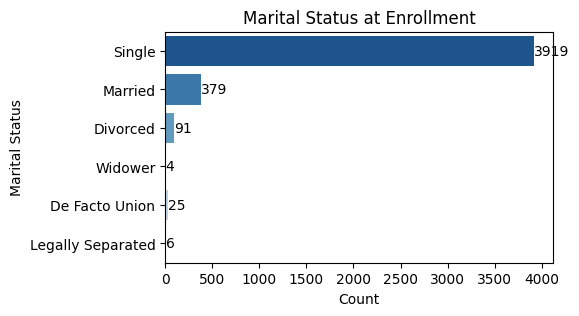

In [14]:
# Plot Bar chart for Marital Status
mapped_data = data[["Marital status"]].iloc[:,0].astype(int).map(marital_status_json)  # map integer to string

plt.figure(figsize=(5, 3))  # set figure size
sns.countplot(
    y=mapped_data,  # assign to y-axis
    hue=mapped_data,  # assign to hue
    palette="Blues_r", # set color palette
    dodge=False,  # do not separate bars
    legend=False # do not show legend
)

plt.title("Marital Status at Enrollment") # set title
plt.xlabel("Count") # set x-axis label
plt.ylabel("Marital Status") # set y-axis label

# Show exact counts on bars
for p in plt.gca().patches:    # iterate over bars
    plt.text(
        p.get_width() + 0.3,   # set x position
        p.get_y() + p.get_height() / 2,  # set y position
        int(p.get_width()), # set text to bar width
        va='center' # vertical alignment
    )

plt.show()  # show plot


The majority of students are single, followed by married and then divorced. Only a small proportion fall under categories such as de facto union, legally separated, or widowed.

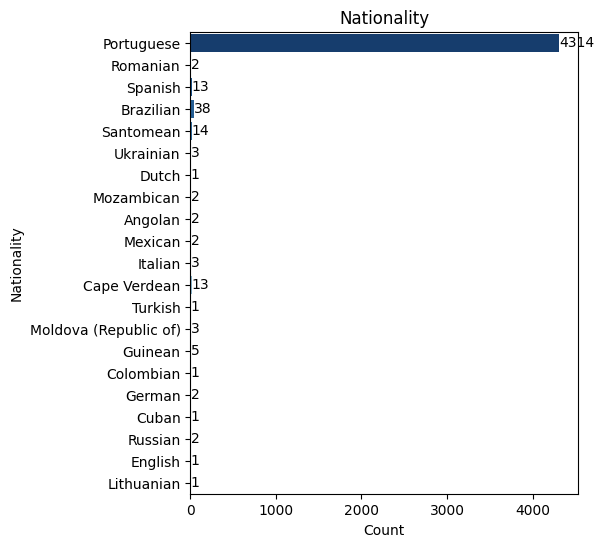

In [15]:
# Plot for Nationality
mapped_data = data[["Nationality"]].iloc[:,0].astype(int).map(nationality_json)  # map integer to string

plt.figure(figsize=(5, 6))  # set figure size
sns.countplot( 
    y=mapped_data,   # assign to y-axis
    hue=mapped_data,  # assign to hue
    palette="Blues_r", # set color palette
    legend=False # do not show legend
)

plt.title("Nationality")  # set title
plt.xlabel("Count")  # set x-axis label
plt.ylabel("Nationality") # set y-axis label

# Show exact counts on bars
for p in plt.gca().patches:  # iterate over bars
    plt.text(
        p.get_width() + 0.3,  # set x position
        p.get_y() + p.get_height() / 2,  # set y position
        int(p.get_width()),  # set text to bar width
        va='center' # vertical alignment
    )
plt.show() # show plot

Most of the students are from Portugese,followed by Brazilian

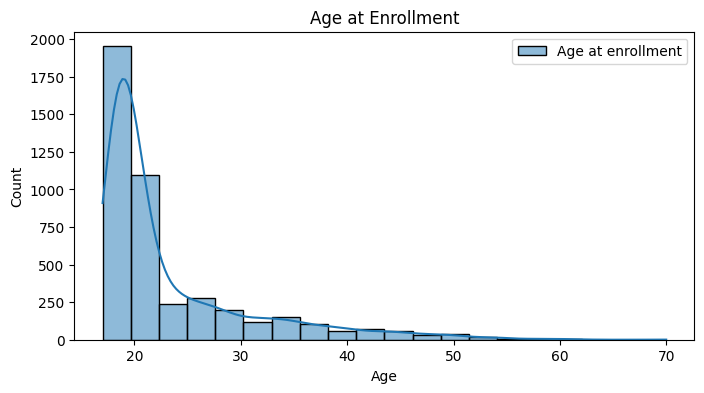

In [16]:
# Plot for Age at Enrollment
plt.figure(figsize=(8, 4))   # set figure size
sns.histplot(data['Age at enrollment'], bins=20, kde=True)  # create histogram
plt.title("Age at Enrollment")  # set title
plt.xlabel("Age")  # set x-axis label
plt.ylabel("Count") # set y-axis label
plt.show()  # show plot

Most students are young, while very few above the age of 30 pursue studies.

In [17]:
# show percentage of displaced students
total_count = data.shape[0]  # total number of students

displaced_students = data['Displaced'].iloc[:,0].map({1: 'Yes', 0: 'No'}).value_counts() # count displaced and not displaced students

num_of_displaced_students = displaced_students[0]  # number of displaced students
num_of_not_displaced_students = displaced_students[1] # number of not displaced students

print("Number of Displaced Students:", num_of_displaced_students)  # print number of displaced students
print("Number of Not Displaced Students:", num_of_not_displaced_students) # print number of not displaced students

print("\nPercentage of Displaced Students:", (num_of_displaced_students / total_count) * 100)  # print percentage of displaced students
print("Percentage of Not Displaced Students:", (num_of_not_displaced_students / total_count) * 100) # print percentage of not displaced students

Number of Displaced Students: 2426
Number of Not Displaced Students: 1998

Percentage of Displaced Students: 54.8372513562387
Percentage of Not Displaced Students: 45.162748643761304


There is good amount of proportion of each displacement status. but, most of the students are displaced from their home town

In [18]:
# show percentage of Gender
gender_counts = data['Gender'].iloc[:,0].map({1: 'Male', 0: 'Female'}).value_counts() # count male and female students

num_of_male_students = gender_counts[0]  # number of male students
num_of_female_students = gender_counts[1] # number of female students

print("Number of Male Students:", num_of_male_students)  # print number of male students
print("Number of Female Students:", num_of_female_students) # print number of female students

print("\nPercentage of Male Students:", (num_of_male_students / total_count) * 100)  # print percentage of male students
print("Percentage of Female Students:", (num_of_female_students / total_count) * 100) # print percentage of female students

Number of Male Students: 2868
Number of Female Students: 1556

Percentage of Male Students: 64.82820976491863
Percentage of Female Students: 35.171790235081374


In [19]:
# show percentage of International Students

international_counts = data['International'].iloc[:,0].map({1: 'Yes', 0: 'No'}).value_counts() # count international and not international students

num_of_international_students = international_counts[0]  # number of international students
num_of_not_international_students = international_counts[1] # number of not international students

print("Number of International Students:", num_of_international_students)  # print number of international students
print("Number of Not International Students:", num_of_not_international_students) # print number of

print("\nPercentage of International Students:", (num_of_international_students / total_count) * 100)  # print percentage of international students
print("Percentage of Not International Students:", (num_of_not_international_students / total_count) * 100) # print percentage of not international students

Number of International Students: 4314
Number of Not International Students: 110

Percentage of International Students: 97.51356238698011
Percentage of Not International Students: 2.4864376130198913


Very few students are from out of the country

#### Exploring the socio-economic data

<table style="border-collapse:collapse;font-family:system-ui,Segoe UI,Arial;font-size:14px;">
  <thead>
    <tr>
      <th style="border:1px solid #ccc;padding:6px; text-align:left; color:#ccc;">Class of Attribute</th>
      <th style="border:1px solid #ccc;padding:6px; text-align:left; color:#ccc;">Attribute</th>
      <th style="border:1px solid #ccc;padding:6px; text-align:left; color:#ccc;">Attribute Type (All are Numeric)</th>
    </tr>
  </thead>
  <tbody>
    <tr><td rowspan="8" style="border:1px solid #ccc;padding:6px;text-align:left;">Socioeconomic data</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Mother’s qualification</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Discrete</td></tr>
    <tr><td style="border:1px solid #ccc;padding:6px;text-align:left;">Father’s qualification</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Discrete</td></tr>
    <tr><td style="border:1px solid #ccc;padding:6px;text-align:left;">Mother’s occupation</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Discrete</td></tr>
    <tr><td style="border:1px solid #ccc;padding:6px;text-align:left;">Father’s occupation</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Discrete</td></tr>
    <tr><td style="border:1px solid #ccc;padding:6px;text-align:left;">Educational special needs</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Binary</td></tr>
    <tr><td style="border:1px solid #ccc;padding:6px;text-align:left;">Debtor</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Binary</td></tr>
    <tr><td style="border:1px solid #ccc;padding:6px;text-align:left;">Tuition fees up to date</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Binary</td></tr>
    <tr><td style="border:1px solid #ccc;padding:6px;text-align:left;">Scholarship holder</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Binary</td></tr>

  </tbody>
</table>

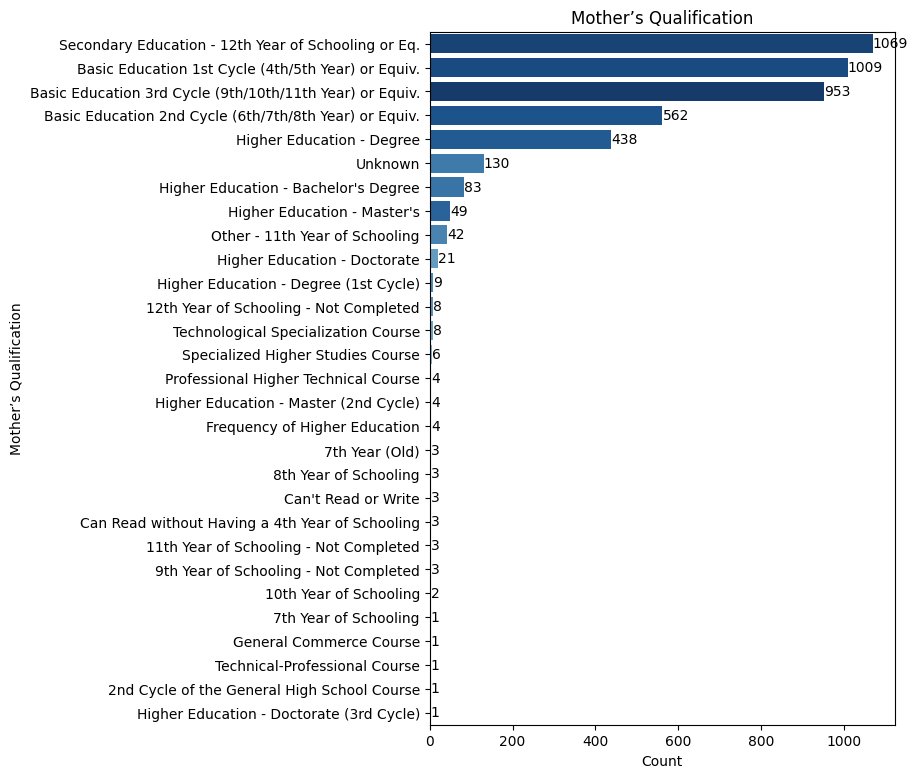

In [20]:
# Plot for Mother’s qualification
mapped_data = data[["Mother's qualification"]].iloc[:,0].astype(int).map(mother_qualifications_json)  # map integer to string

plt.figure(figsize=(6, 9)) # set figure size

# Map values
mother_qual = mapped_data  # assign to mother_qual

# Get counts and sort (descending)
order = mother_qual.value_counts(ascending=True).index  # get sorted order

sns.countplot(
    y=mother_qual,              # assign to y-axis
    order=order,                # apply sorted order
    hue=mother_qual,            # needed for palette
    palette="Blues_r",          # set color palette
    legend=False                # do not show legend
)

plt.title("Mother’s Qualification")   # set title
plt.xlabel("Count")                   # set x-axis label
plt.ylabel("Mother’s Qualification")  # set y-axis label

# Show exact counts on bars
for p in plt.gca().patches:   # iterate over bars
    plt.text(
        p.get_width() + 0.3,  # set x position
        p.get_y() + p.get_height() / 2,  # set y position
        int(p.get_width()),              # set text to bar width
        va='center'                      # vertical alignment
    )

plt.gca().invert_yaxis()    # invert y-axis to have the highest count on top
plt.show()                  # show plot


Most of the Mother's qualifications are Basic Educations, followed by Secondary Educations. Very few have a Degree.

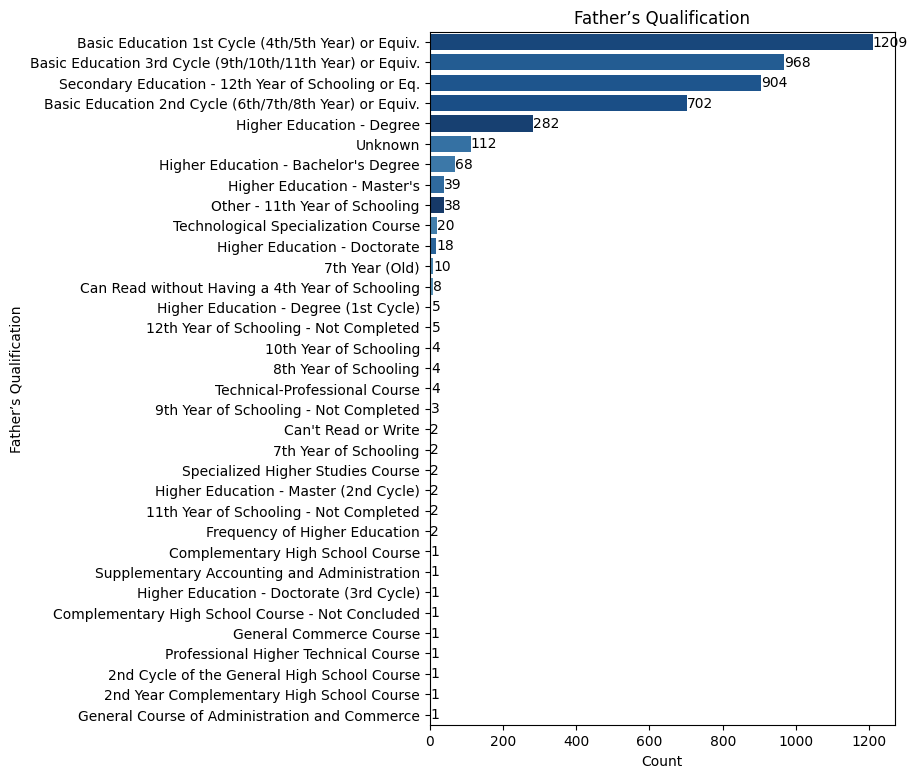

In [21]:
# Plot for Father’s qualification
mapped_data = data[["Father's qualification"]].iloc[:,0].astype(int).map(father_qualifications_json)    # map integer to string

plt.figure(figsize=(6, 9))    # set figure size
father_qual = mapped_data     # assign to father_qual

order = father_qual.value_counts(ascending=True).index   # get sorted order

sns.countplot(
    y=father_qual,              # assign to y-axis
    order=order,                # apply sorted order
    hue=father_qual,            # needed for palette
    palette="Blues_r",          # set color palette
    legend=False                # do not show legend
)
plt.title("Father’s Qualification")   # set title
plt.xlabel("Count")                   # set x-axis label
plt.ylabel("Father’s Qualification")  # set y-axis label


for p in plt.gca().patches:
    plt.text(
        p.get_width() + 0.3,             # set x position
        p.get_y() + p.get_height() / 2,  # set y position
        int(p.get_width()),              # set text to bar width
        va='center'                      # vertical alignment
    )

plt.gca().invert_yaxis()    # invert y-axis to have the highest count on top
plt.show()                  # show plot

Most of the Father's qualifications are Basic Educations, followed by Secondary Educations. Very few have a Degree.

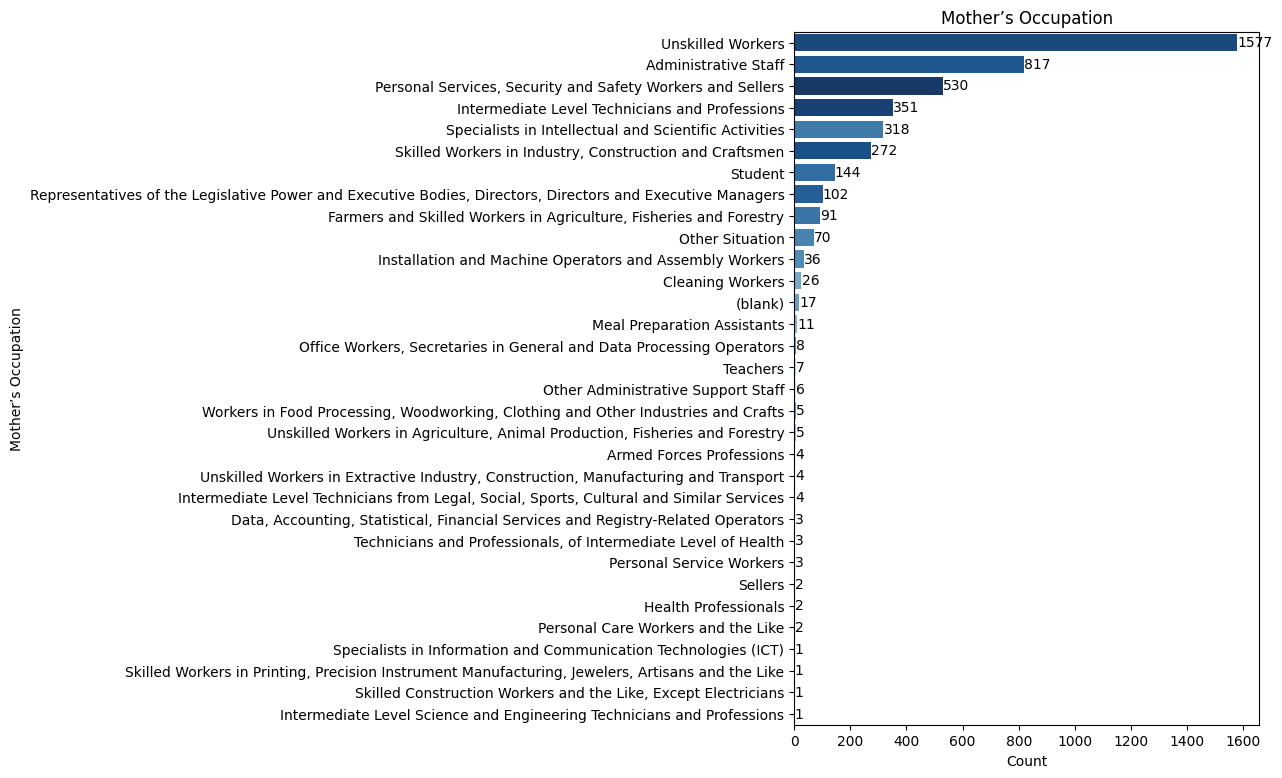

In [22]:
# Plot for Mother’s occupation
mapped_data = data[["Mother's occupation"]].iloc[:,0].astype(int).map(mother_occupations_json)    # map integer to string

plt.figure(figsize=(6, 9))   # set figure size

mother_occ = mapped_data     # assign to mother_occ

order = mother_occ.value_counts(ascending=True).index   # get sorted order

sns.countplot(
    y=mother_occ,              # assign to y-axis
    order=order,               # apply sorted order
    hue=mother_occ,            # needed for palette
    palette="Blues_r",         # set color palette
    legend=False               # do not show legend
)

plt.title("Mother’s Occupation")  # set title
plt.xlabel("Count")               # set x-axis label
plt.ylabel("Mother’s Occupation") # set y-axis label

for p in plt.gca().patches:    # iterate over bars
    plt.text( 
        p.get_width() + 0.3,   # set x position
        p.get_y() + p.get_height() / 2,  # set y position
        int(p.get_width()),         # set text to bar width
        va='center'             # vertical alignment
    )
plt.gca().invert_yaxis()    # invert y-axis to have the highest count on top
plt.show()                  # show plot

In [23]:
# show percentage of Educational special needs
educational_special_needs_counts = data['Educational special needs'].iloc[:,0].map({1: 'Yes', 0: 'No'}).value_counts() # count special needs and not special needs students

num_of_educational_special_needs_students = educational_special_needs_counts[0]  # number of special needs students
num_of_not_educational_special_needs_students = educational_special_needs_counts[1] # number of not special needs students

print("Number of Educational Special Needs Students:", num_of_educational_special_needs_students)  # print number of special needs students
print("Number of Not Educational Special Needs Students:", num_of_not_educational_special_needs_students) # print number of not special needs students

print("\nPercentage of Educational Special Needs Students:", (num_of_educational_special_needs_students / total_count) * 100)  # print percentage of special needs students
print("Percentage of Not Educational Special Needs Students:", (num_of_not_educational_special_needs_students / total_count) * 100) # print percentage of not special needs students

Number of Educational Special Needs Students: 4373
Number of Not Educational Special Needs Students: 51

Percentage of Educational Special Needs Students: 98.84719710669077
Percentage of Not Educational Special Needs Students: 1.1528028933092225


A very few students have Educational special needs

In [24]:
# show percentage of Debtor students
debt_counts = data['Debtor'].iloc[:,0].map({1: 'Yes', 0: 'No'}).value_counts() # count debtor and not debtor students

num_of_debtor_students = debt_counts[0]  # number of debtor students
num_of_not_debtor_students = debt_counts[1] # number of not debtor students

print("Number of Debtor Students:", num_of_debtor_students)  # print number of debtor students
print("Number of Not Debtor Students:", num_of_not_debtor_students) # print number of not debtor students

print("\nPercentage of Debtor Students:", (num_of_debtor_students / total_count) * 100)  # print percentage of debtor students
print("Percentage of Not Debtor Students:", (num_of_not_debtor_students / total_count) * 100) # print percentage of not debtor students

Number of Debtor Students: 3921
Number of Not Debtor Students: 503

Percentage of Debtor Students: 88.63019891500905
Percentage of Not Debtor Students: 11.369801084990959


In [25]:
# show percentage of Tution fees up to date
tution_fees_counts = data['Tuition fees up to date'].iloc[:,0].map({1: 'Yes', 0: 'No'}).value_counts() # count tution fees up to date and not up to date students

num_of_tution_fees_up_to_date_students = tution_fees_counts[0]  # number of tution fees up to date students
num_of_tution_fees_not_up_to_date_students = tution_fees_counts[1] # number of tution fees not up to date students

print("Number of Tution Fees Up to Date Students:", num_of_tution_fees_up_to_date_students)  # print number of tution fees up to date students
print("Number of Tution Fees Not Up to Date Students:", num_of_tution_fees_not_up_to_date_students) # print number of tution fees not up to date students

print("\nPercentage of Tution Fees Up to Date Students:", (num_of_tution_fees_up_to_date_students / total_count) * 100)  # print percentage of tution fees up to date students
print("Percentage of Tution Fees Not Up to Date Students:", (num_of_tution_fees_not_up_to_date_students / total_count) * 100) # print percentage of tution fees not up to date students

Number of Tution Fees Up to Date Students: 3896
Number of Tution Fees Not Up to Date Students: 528

Percentage of Tution Fees Up to Date Students: 88.06509945750453
Percentage of Tution Fees Not Up to Date Students: 11.934900542495479


In [26]:
# show percentage of Scholarship holder
scholarship_counts = data['Scholarship holder'].iloc[:,0].map({1: 'Yes', 0: 'No'}).value_counts() # count scholarship holder and not scholarship holder students

num_of_scholarship_holder_students = scholarship_counts[0]  # number of scholarship holder students
num_of_not_scholarship_holder_students = scholarship_counts[1] # number of not scholarship holder students

print("Number of Scholarship Holder Students:", num_of_scholarship_holder_students)  # print number of scholarship holder students
print("Number of Not Scholarship Holder Students:", num_of_not_scholarship_holder_students) # print number of not scholarship holder students

print("\nPercentage of Scholarship Holder Students:", (num_of_scholarship_holder_students / total_count) * 100)  # print percentage of scholarship holder students
print("Percentage of Not Scholarship Holder Students:", (num_of_not_scholarship_holder_students / total_count) * 100) # print percentage of not scholarship holder students

Number of Scholarship Holder Students: 3325
Number of Not Scholarship Holder Students: 1099

Percentage of Scholarship Holder Students: 75.15822784810126
Percentage of Not Scholarship Holder Students: 24.841772151898734


#### Exploring the socio-economic data

<table style="border-collapse:collapse;font-family:system-ui,Segoe UI,Arial;font-size:14px;">
  <thead>
    <tr>
      <th style="border:1px solid #ccc;padding:6px; text-align:left; color:#ccc;">Class of Attribute</th>
      <th style="border:1px solid #ccc;padding:6px; text-align:left; color:#ccc;">Attribute</th>
      <th style="border:1px solid #ccc;padding:6px; text-align:left; color:#ccc;">Attribute Type (All are Numeric)</th>
    </tr>
  </thead>
  <tbody>
    <tr><td rowspan="3" style="border:1px solid #ccc;padding:6px;text-align:left;">Economic data</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Unemployment rate</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Continuous</td></tr>
    <tr><td style="border:1px solid #ccc;padding:6px;text-align:left;">Inflation rate</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Continuous</td></tr>
    <tr><td style="border:1px solid #ccc;padding:6px;text-align:left;">GDP</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Continuous</td></tr>
</tbody>
</table>

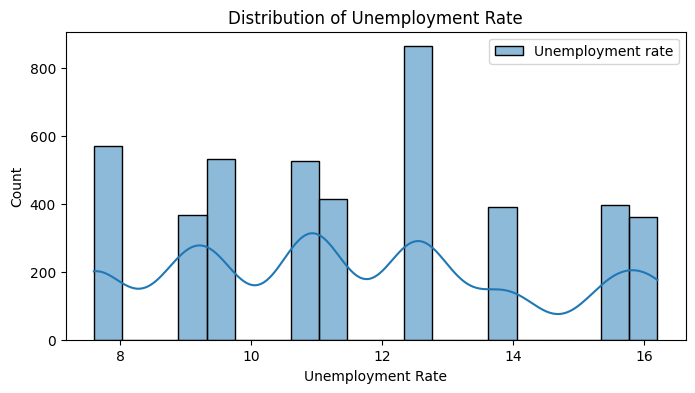

In [27]:
# Plot for Unemployment rate
plt.figure(figsize=(8, 4))

# Create histogram plot directly without sorting
sns.histplot(data['Unemployment rate'], bins=20, kde=True)

plt.title("Distribution of Unemployment Rate")  # set title
plt.xlabel("Unemployment Rate")  # set x-axis label
plt.ylabel("Count") # set y-axis label
plt.show()  # show plot


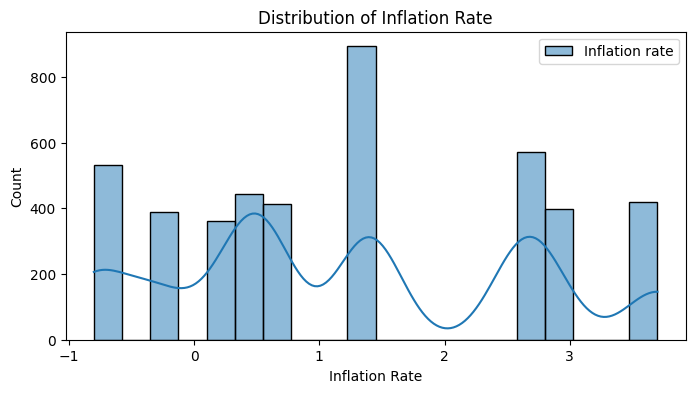

In [28]:
# Plot for Inflation rate
plt.figure(figsize=(8, 4))
# Create histogram plot directly without sorting
sns.histplot(data['Inflation rate'], bins=20, kde=True)
plt.title("Distribution of Inflation Rate")
plt.xlabel("Inflation Rate")
plt.ylabel("Count")
plt.show()

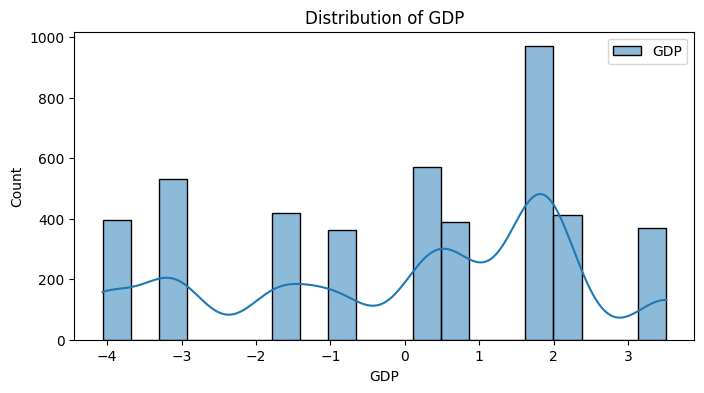

In [29]:
# Plot for GDP
plt.figure(figsize=(8, 4))
# Create histogram plot directly without sorting
sns.histplot(data['GDP'], bins=20, kde=True)
plt.title("Distribution of GDP")
plt.xlabel("GDP")
plt.ylabel("Count")
plt.show()

#### Exploring the academic data

<table style="border-collapse:collapse;font-family:system-ui,Segoe UI,Arial;font-size:14px;">
  <thead>
    <tr>
      <th style="border:1px solid #ccc;padding:6px; text-align:left; color:#ccc;">Class of Attribute</th>
      <th style="border:1px solid #ccc;padding:6px; text-align:left; color:#ccc;">Attribute</th>
      <th style="border:1px solid #ccc;padding:6px; text-align:left; color:#ccc;">Attribute Type (All are Numeric)</th>
    </tr>
  </thead>
  <tbody>
    <tr><td rowspan="5" style="border:1px solid #ccc;padding:6px;text-align:left;">Academic data at enrollment</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Application mode</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Discrete</td></tr>
    <tr><td style="border:1px solid #ccc;padding:6px;text-align:left;">Application order</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Ordinal</td></tr>
    <tr><td style="border:1px solid #ccc;padding:6px;text-align:left;">Course</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Discrete</td></tr>
    <tr><td style="border:1px solid #ccc;padding:6px;text-align:left;">Daytime/evening attendance</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Binary</td></tr>
    <tr><td style="border:1px solid #ccc;padding:6px;text-align:left;">Previous qualification</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Discrete</td></tr>

</tbody>
</table>

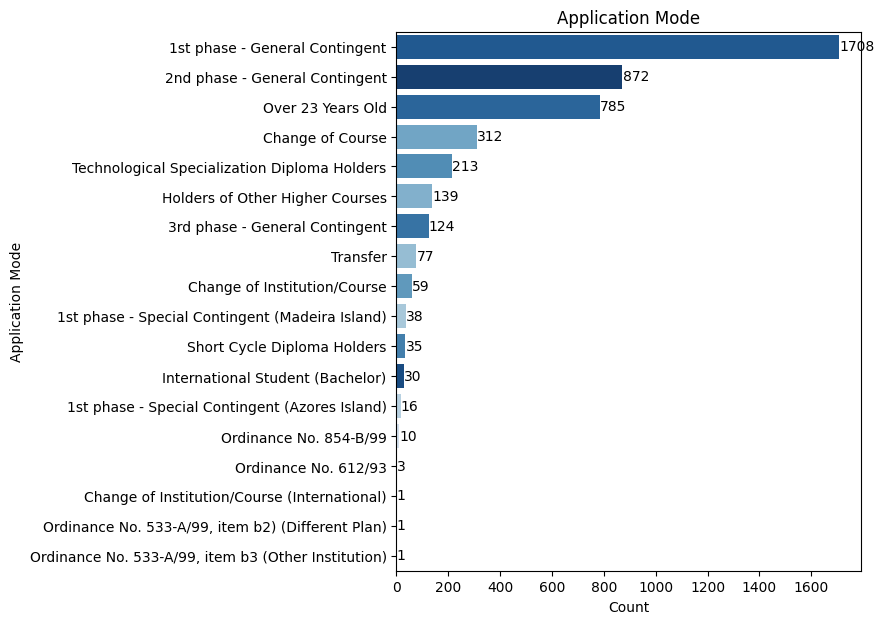

In [30]:
# Plot for Application mode
mapped_data = data[["Application mode"]].iloc[:,0].astype(int).map(application_mode_json)   # map integer to string

# sort according to counts
order = mapped_data.value_counts(ascending=False).index    # get sorted order

plt.figure(figsize=(6, 7))  # set figure size

sns.countplot(
    y=mapped_data,    # assign to y-axis
    hue=mapped_data,  # assign to hue
    palette="Blues_r", # set color palette
    legend=False,      # do not show legend
    order=order        # apply sorted order
)

plt.title("Application Mode")   # set title
plt.xlabel("Count")             # set x-axis label
plt.ylabel("Application Mode")  # set y-axis label

for p in plt.gca().patches:     # iterate over bars
    plt.text(
        p.get_width() + 0.3,         # set x position
        p.get_y() + p.get_height() / 2, # set y position
        int(p.get_width()),         # set text to bar width
        va='center'                 # vertical alignment
    )

plt.show()    # show plot

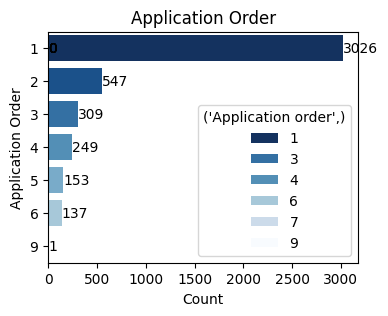

In [31]:
# Plot for Application order

app_order = data[["Application order"]].iloc[:,0].astype(int)[1:]    # convert to integer
order = app_order.value_counts().sort_index().index[1:]  # sort by category value
app_order = app_order[app_order != 0]   # remove 0th position

plt.figure(figsize=(4, 3))    # set figure size

sns.countplot(
    y=app_order,             # assign to y-axis
    hue=app_order,          # assign to hue
    order=order,           # ensure sorted order
    palette="Blues_r"      # set color palette
)

plt.title("Application Order")   # set title
plt.xlabel("Count")              # set x-axis label
plt.ylabel("Application Order")  # set y-axis label

# Show exact counts on bars
for p in plt.gca().patches:    # iterate over bars
    if p == 0:
        continue
    plt.text(
        p.get_width() + 0.3,   # set x position
        p.get_y() + p.get_height() / 2,  # set y position
        int(p.get_width()),      # set text to bar width
        va='center'              # vertical alignment
    )

plt.show()                  # show plot


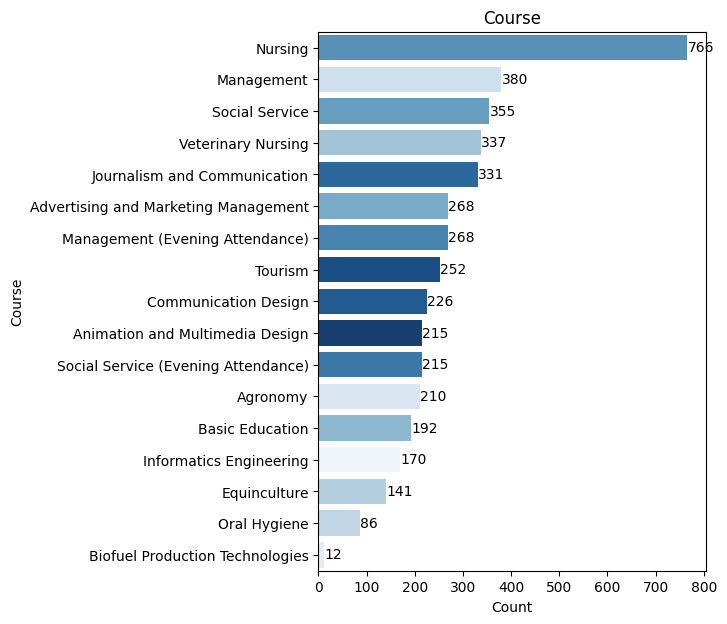

In [32]:
# Plot for Course
mapped_data = data[["Course"]].iloc[:,0].astype(int).map(course_json)  # map integer to string
order = mapped_data.value_counts(ascending=False).index  # get sorted order
plt.figure(figsize=(5, 7))  # set figure size

sns.countplot(
    y=mapped_data,    # assign to y-axis
    hue=mapped_data,  # assign to hue
    palette="Blues_r", # set color palette
    legend=False,     # do not show legend
    order=order       # apply sorted order
)

plt.title("Course")            # set title
plt.xlabel("Count")            # set x-axis label
plt.ylabel("Course")           # set y-axis label

for p in plt.gca().patches:    # iterate over bars
    plt.text(
        p.get_width() + 0.3,   # set x position
        p.get_y() + p.get_height() / 2,  # set y position
        int(p.get_width()),    # set text to bar width
        va='center'            # vertical alignment
    )
plt.show()   # show plot

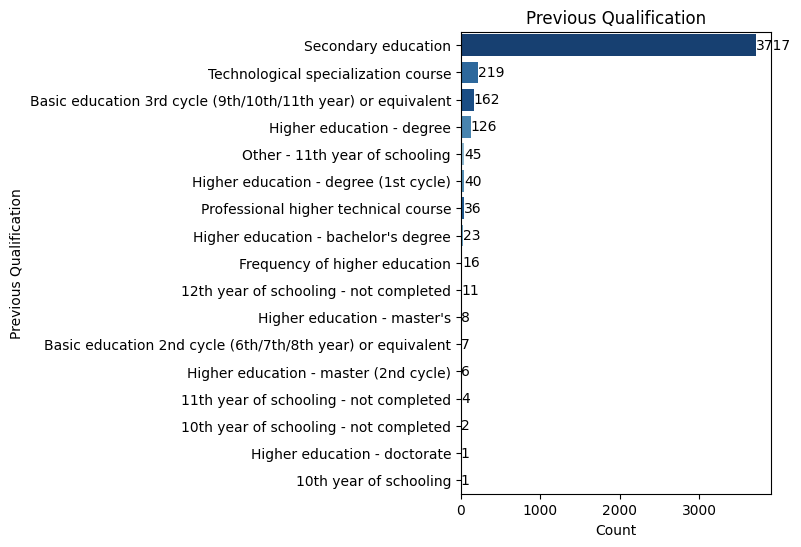

In [33]:
# Plot for Previous qualification
mapped_data = data[["Previous qualification"]].iloc[:,0].astype(int).map(previous_qualification_json)   # map integer to string
order = mapped_data.value_counts(ascending=True).index   # get sorted order
plt.figure(figsize=(4, 6))    # set figure size

sns.countplot(
    y=mapped_data,    # assign to y-axis
    hue=mapped_data,  # assign to hue
    palette="Blues_r", # set color palette
    legend=False,    # do not show legend
    order=order       # apply sorted order
) 

plt.title("Previous Qualification")   # set title
plt.xlabel("Count")                   # set x-axis label
plt.ylabel("Previous Qualification")  # set y-axis label

for p in plt.gca().patches:    # iterate over bars
    plt.text( 
        p.get_width() + 0.3,   # set x position
        p.get_y() + p.get_height() / 2,   # set y position
        int(p.get_width()),       # set text to bar width
        va='center'            # vertical alignment
    )

plt.gca().invert_yaxis()       # invert y-axis to have the highest count on top
plt.show()                     # show plot

In [34]:
# show percentage of Daytime/evening attendance
daytime_evening_counts = data['Daytime/evening attendance'].iloc[:,0].map({1: 'Evening', 0: 'Daytime'}).value_counts() # count daytime and evening students

num_of_daytime_students = daytime_evening_counts[0]  # number of daytime students
num_of_evening_students = daytime_evening_counts[1] # number of evening students

print("Number of Daytime Students:", num_of_daytime_students)  # print number of daytime students
print("Number of Evening Students:", num_of_evening_students) # print number of evening students

print("\nPercentage of Daytime Students:", (num_of_daytime_students / total_count) * 100)  # print percentage of daytime students
print("Percentage of Evening Students:", (num_of_evening_students / total_count) * 100) # print percentage of evening students

Number of Daytime Students: 3941
Number of Evening Students: 483

Percentage of Daytime Students: 89.08227848101265
Percentage of Evening Students: 10.917721518987342


#### Exploring the Academic data

<table style="border-collapse:collapse;font-family:system-ui,Segoe UI,Arial;font-size:14px;">
  <thead>
    <tr>
      <th style="border:1px solid #ccc;padding:6px; text-align:left; color:#ccc;">Class of Attribute</th>
      <th style="border:1px solid #ccc;padding:6px; text-align:left; color:#ccc;">Attribute</th>
      <th style="border:1px solid #ccc;padding:6px; text-align:left; color:#ccc;">Attribute Type (All are Numeric)</th>
    </tr>
  </thead>
  <tbody>
<tr><td rowspan="6" style="border:1px solid #ccc;padding:6px;text-align:left;">Academic data at the end of 1st semester</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Curricular units 1st sem (credited)</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Discrete</td></tr>
    <tr><td style="border:1px solid #ccc;padding:6px;text-align:left;">Curricular units 1st sem (enrolled)</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Discrete</td></tr>
    <tr><td style="border:1px solid #ccc;padding:6px;text-align:left;">Curricular units 1st sem (evaluations)</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Discrete</td></tr>
    <tr><td style="border:1px solid #ccc;padding:6px;text-align:left;">Curricular units 1st sem (approved)</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Discrete</td></tr>
    <tr><td style="border:1px solid #ccc;padding:6px;text-align:left;">Curricular units 1st sem (grade)</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Continuous</td></tr>
    <tr><td style="border:1px solid #ccc;padding:6px;text-align:left;">Curricular units 1st sem (without evaluations)</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Discrete</td></tr>

</tbody>
</table>

In [35]:
# show percentage of Curricular units 1st sem (credited)
curricular_units_1st_sem_credited_counts = data['Curricular units 1st sem (credited)'].iloc[:,0].map({1: 'Yes', 0: 'No'}).value_counts() # count credited and not credited students

num_of_curricular_units_1st_sem_credited_students = curricular_units_1st_sem_credited_counts[0]  # number of credited students
num_of_curricular_units_1st_sem_not_credited_students = curricular_units_1st_sem_credited_counts[1] # number of not credited students

print("Number of Curricular units 1st sem (credited) Students:", num_of_curricular_units_1st_sem_credited_students)  # print number of credited students
print("Number of Curricular units 1st sem (not credited) Students:", num_of_curricular_units_1st_sem_not_credited_students) # print number of not credited students

print("\nPercentage of Curricular units 1st sem (credited) Students:", (num_of_curricular_units_1st_sem_credited_students / total_count) * 100)  # print percentage of credited students
print("Percentage of Curricular units 1st sem (not credited) Students:", (num_of_curricular_units_1st_sem_not_credited_students / total_count) * 100) # print percentage of not credited students

Number of Curricular units 1st sem (credited) Students: 3847
Number of Curricular units 1st sem (not credited) Students: 85

Percentage of Curricular units 1st sem (credited) Students: 86.95750452079565
Percentage of Curricular units 1st sem (not credited) Students: 1.9213381555153706


In [36]:
# show percentage of Curricular units 1st sem (enrolled)
curricular_units_1st_sem_enrolled_counts = data['Curricular units 1st sem (enrolled)'].iloc[:,0].map({1: 'Yes', 0: 'No'}).value_counts()

num_of_curricular_units_1st_sem_enrolled_students = curricular_units_1st_sem_enrolled_counts[0]  # number of enrolled students
num_of_curricular_units_1st_sem_not_enrolled_students = curricular_units_1st_sem_enrolled_counts[1] # number of not enrolled students

print("Number of Curricular units 1st sem (enrolled) Students:", num_of_curricular_units_1st_sem_enrolled_students)  # print number of enrolled students
print("Number of Curricular units 1st sem (not enrolled) Students:", num_of_curricular_units_1st_sem_not_enrolled_students) # print number of not enrolled students

print("\nPercentage of Curricular units 1st sem (enrolled) Students:", (num_of_curricular_units_1st_sem_enrolled_students / total_count) * 100)  # print percentage of enrolled students
print("Percentage of Curricular units 1st sem (not enrolled) Students:", (num_of_curricular_units_1st_sem_not_enrolled_students / total_count) * 100) # print percentage of not enrolled students


Number of Curricular units 1st sem (enrolled) Students: 180
Number of Curricular units 1st sem (not enrolled) Students: 7

Percentage of Curricular units 1st sem (enrolled) Students: 4.06871609403255
Percentage of Curricular units 1st sem (not enrolled) Students: 0.15822784810126583


In [37]:
# show percentage of Curricular units 1st sem (evaluations)
curricular_units_1st_sem_evaluations_counts = data['Curricular units 1st sem (evaluations)'].iloc[:,0].map({1: 'Yes', 0: 'No'}).value_counts()

num_of_curricular_units_1st_sem_evaluated_students = curricular_units_1st_sem_evaluations_counts[0]  # number of evaluated students
num_of_curricular_units_1st_sem_not_evaluated_students = curricular_units_1st_sem_evaluations_counts[1] # number of not evaluated students

print("Number of Curricular units 1st sem (evaluated) Students:", num_of_curricular_units_1st_sem_evaluated_students)  # print number of evaluated students
print("Number of Curricular units 1st sem (not evaluated) Students:", num_of_curricular_units_1st_sem_not_evaluated_students) # print number of not evaluated students

print("\nPercentage of Curricular units 1st sem (evaluated) Students:", (num_of_curricular_units_1st_sem_evaluated_students / total_count) * 100)  # print percentage of evaluated students
print("Percentage of Curricular units 1st sem (not evaluated) Students:", (num_of_curricular_units_1st_sem_not_evaluated_students / total_count) * 100) # print percentage of not evaluated students

Number of Curricular units 1st sem (evaluated) Students: 349
Number of Curricular units 1st sem (not evaluated) Students: 6

Percentage of Curricular units 1st sem (evaluated) Students: 7.88878842676311
Percentage of Curricular units 1st sem (not evaluated) Students: 0.13562386980108498


In [38]:
# show percentage of Curricular units 1st sem (approved)
curricular_units_1st_sem_approved_counts = data['Curricular units 1st sem (approved)'].iloc[:,0].map({1: 'Yes', 0: 'No'}).value_counts()

num_of_curricular_units_1st_sem_approved_students = curricular_units_1st_sem_approved_counts[0]  # number of approved students
num_of_curricular_units_1st_sem_not_approved_students = curricular_units_1st_sem_approved_counts[1] # number of not approved students

print("Number of Curricular units 1st sem (approved) Students:", num_of_curricular_units_1st_sem_approved_students)  # print number of approved students
print("Number of Curricular units 1st sem (not approved) Students:", num_of_curricular_units_1st_sem_not_approved_students) # print number of not approved students

print("\nPercentage of Curricular units 1st sem (approved) Students:", (num_of_curricular_units_1st_sem_approved_students / total_count) * 100)  # print percentage of approved students
print("Percentage of Curricular units 1st sem (not approved) Students:", (num_of_curricular_units_1st_sem_not_approved_students / total_count) * 100) # print percentage of not approved students

Number of Curricular units 1st sem (approved) Students: 718
Number of Curricular units 1st sem (not approved) Students: 127

Percentage of Curricular units 1st sem (approved) Students: 16.229656419529835
Percentage of Curricular units 1st sem (not approved) Students: 2.870705244122966


In [39]:
# show percentage of Curricular units 1st sem (without evaluations)
curricular_units_1st_sem_without_evaluations_counts = data['Curricular units 1st sem (without evaluations)'].iloc[:,0].map({1: 'Yes', 0: 'No'}).value_counts() # count without evaluations and with evaluations students

num_of_curricular_units_1st_sem_without_evaluations_students = curricular_units_1st_sem_without_evaluations_counts[0]  # number of without evaluations students
num_of_curricular_units_1st_sem_with_evaluations_students = curricular_units_1st_sem_without_evaluations_counts[1] # number of with evaluations students

print("Number of Curricular units 1st sem (without evaluations) Students:", num_of_curricular_units_1st_sem_without_evaluations_students)  # print number of without evaluations students
print("Number of Curricular units 1st sem (with evaluations) Students:", num_of_curricular_units_1st_sem_with_evaluations_students) # print number of with evaluations students

print("\nPercentage of Curricular units 1st sem (without evaluations) Students:", (num_of_curricular_units_1st_sem_without_evaluations_students / total_count) * 100)  # print percentage of without evaluations students
print("Percentage of Curricular units 1st sem (with evaluations) Students:", (num_of_curricular_units_1st_sem_with_evaluations_students / total_count) * 100) # print percentage of with evaluations students

Number of Curricular units 1st sem (without evaluations) Students: 4130
Number of Curricular units 1st sem (with evaluations) Students: 153

Percentage of Curricular units 1st sem (without evaluations) Students: 93.35443037974683
Percentage of Curricular units 1st sem (with evaluations) Students: 3.4584086799276674


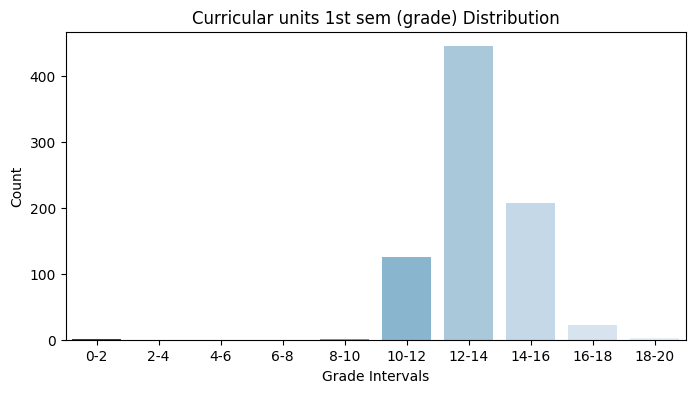

In [40]:
# Plot grade as intervals of Curricular units 1st sem (grade)

# Extract raw grade values (as Series)
curricular_units_1st_sem_grade_values = data['Curricular units 1st sem (grade)'].iloc[:,0].value_counts()

# Define bins and labels
bins = [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
labels = ['0-2', '2-4', '4-6', '6-8', '8-10', '10-12', '12-14', '14-16', '16-18', '18-20']

# convert series to dataframe 
curricular_units_1st_sem_grade_df = curricular_units_1st_sem_grade_values.reset_index()
curricular_units_1st_sem_grade_df.columns = ['Grade', 'Count']  # rename columns

# Bin the grades into intervals
curricular_units_1st_sem_grade_df["Curricular units 1st sem (grade) binned"] = pd.cut(curricular_units_1st_sem_grade_df["Grade"], bins=bins, labels=labels, right=False)

# Plot the binned grades
plt.figure(figsize=(8, 4))  # set figure size
sns.countplot(
    x='Curricular units 1st sem (grade) binned',  # assign to x-axis
    data=curricular_units_1st_sem_grade_df,       # assign data
    palette="Blues_r",                            # set color palette
    order=labels  # ensure order is respected
)

plt.title("Curricular units 1st sem (grade) Distribution")  # set title
plt.xlabel("Grade Intervals")                       # set x-label
plt.ylabel("Count")                      # set y-label
plt.show()  # show plot

<table style="border-collapse:collapse;font-family:system-ui,Segoe UI,Arial;font-size:14px;">
  <thead>
    <tr>
      <th style="border:1px solid #ccc;padding:6px; text-align:left; color:#ccc;">Class of Attribute</th>
      <th style="border:1px solid #ccc;padding:6px; text-align:left; color:#ccc;">Attribute</th>
      <th style="border:1px solid #ccc;padding:6px; text-align:left; color:#ccc;">Attribute Type (All are Numeric)</th>
    </tr>
  </thead>
  <tbody>
 <tr><td rowspan="6" style="border:1px solid #ccc;padding:6px;text-align:left;">Academic data at the end of 2nd semester</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Curricular units 2nd sem (credited)</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Discrete</td></tr>
    <tr><td style="border:1px solid #ccc;padding:6px;text-align:left;">Curricular units 2nd sem (enrolled)</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Discrete</td></tr>
    <tr><td style="border:1px solid #ccc;padding:6px;text-align:left;">Curricular units 2nd sem (evaluations)</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Discrete</td></tr>
    <tr><td style="border:1px solid #ccc;padding:6px;text-align:left;">Curricular units 2nd sem (approved)</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Discrete</td></tr>
    <tr><td style="border:1px solid #ccc;padding:6px;text-align:left;">Curricular units 2nd sem (grade)</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Continuous</td></tr>
    <tr><td style="border:1px solid #ccc;padding:6px;text-align:left;">Curricular units 2nd sem (without evaluations)</td><td style="border:1px solid #ccc;padding:6px;text-align:left;">Discrete</td></tr>

</tbody>
</table>

In [41]:
# show percentage of Curricular units 2st sem (credited)
curricular_units_2nd_sem_credited_counts = data['Curricular units 2nd sem (credited)'].iloc[:,0].map({1: 'Yes', 0: 'No'}).value_counts() # count credited and not credited students

num_of_curricular_units_2nd_sem_credited_students = curricular_units_2nd_sem_credited_counts[0]  # number of credited students
num_of_curricular_units_2nd_sem_not_credited_students = curricular_units_2nd_sem_credited_counts[1] # number of not credited students

print("Number of Curricular units 2nd sem (credited) Students:", num_of_curricular_units_2nd_sem_credited_students)  # print number of credited students
print("Number of Curricular units 2nd sem (not credited) Students:", num_of_curricular_units_2nd_sem_not_credited_students) # print number of not credited students

print("\nPercentage of Curricular units 2nd sem (credited) Students:", (num_of_curricular_units_2nd_sem_credited_students / total_count) * 100)  # print percentage of credited students
print("Percentage of Curricular units 2nd sem (not credited) Students:", (num_of_curricular_units_2nd_sem_not_credited_students / total_count) * 100) # print percentage of not credited students

Number of Curricular units 2nd sem (credited) Students: 3894
Number of Curricular units 2nd sem (not credited) Students: 107

Percentage of Curricular units 2nd sem (credited) Students: 88.01989150090415
Percentage of Curricular units 2nd sem (not credited) Students: 2.418625678119349


In [42]:
# show percentage of Curricular units 2st sem (enrolled)
curricular_units_2nd_sem_enrolled_counts = data['Curricular units 2nd sem (enrolled)'].iloc[:,0].map({1: 'Yes', 0: 'No'}).value_counts() # count enrolled and not enrolled students

num_of_curricular_units_2nd_sem_enrolled_students = curricular_units_2nd_sem_enrolled_counts[0]  # number of enrolled students
num_of_curricular_units_2nd_sem_not_enrolled_students = curricular_units_2nd_sem_enrolled_counts[1] # number of not enrolled students

print("Number of Curricular units 2nd sem (enrolled) Students:", num_of_curricular_units_2nd_sem_enrolled_students)  # print number of enrolled students
print("Number of Curricular units 2nd sem (not enrolled) Students:", num_of_curricular_units_2nd_sem_not_enrolled_students) # print number of not enrolled students

print("\nPercentage of Curricular units 2nd sem (enrolled) Students:", (num_of_curricular_units_2nd_sem_enrolled_students / total_count) * 100)  # print percentage of enrolled students
print("Percentage of Curricular units 2nd sem (not enrolled) Students:", (num_of_curricular_units_2nd_sem_not_enrolled_students / total_count) * 100) # print percentage of not enrolled students

Number of Curricular units 2nd sem (enrolled) Students: 180
Number of Curricular units 2nd sem (not enrolled) Students: 3

Percentage of Curricular units 2nd sem (enrolled) Students: 4.06871609403255
Percentage of Curricular units 2nd sem (not enrolled) Students: 0.06781193490054249


In [43]:
# show percentage of Curricular units 2st sem evaluations
curricular_units_2nd_sem_evaluations_counts = data['Curricular units 2nd sem (evaluations)'].iloc[:,0].map({1: 'Yes', 0: 'No'}).value_counts() # count evaluated and not evaluated students

num_of_curricular_units_2nd_sem_evaluated_students = curricular_units_2nd_sem_evaluations_counts[0]  # number of evaluated students
num_of_curricular_units_2nd_sem_not_evaluated_students = curricular_units_2nd_sem_evaluations_counts[1] # number of not evaluated students

print("Number of Curricular units 2nd sem (evaluated) Students:", num_of_curricular_units_2nd_sem_evaluated_students)  # print number of evaluated students
print("Number of Curricular units 2nd sem (not evaluated) Students:", num_of_curricular_units_2nd_sem_not_evaluated_students) # print number of not evaluated students

print("\nPercentage of Curricular units 2nd sem (evaluated) Students:", (num_of_curricular_units_2nd_sem_evaluated_students / total_count) * 100)  # print percentage of evaluated students
print("Percentage of Curricular units 2nd sem (not evaluated) Students:", (num_of_curricular_units_2nd_sem_not_evaluated_students / total_count) * 100) # print percentage of not evaluated students

Number of Curricular units 2nd sem (evaluated) Students: 401
Number of Curricular units 2nd sem (not evaluated) Students: 3

Percentage of Curricular units 2nd sem (evaluated) Students: 9.064195298372514
Percentage of Curricular units 2nd sem (not evaluated) Students: 0.06781193490054249


In [44]:
# show percentage of Curricular units 2st sem approved
curricular_units_2nd_sem_approved_counts = data['Curricular units 2nd sem (approved)'].iloc[:,0].map({1: 'Yes', 0: 'No'}).value_counts() # count approved and not approved students

num_of_curricular_units_2nd_sem_approved_students = curricular_units_2nd_sem_approved_counts[0]  # number of approved students
num_of_curricular_units_2nd_sem_not_approved_students = curricular_units_2nd_sem_approved_counts[1] # number of not approved students

print("Number of Curricular units 2nd sem (approved) Students:", num_of_curricular_units_2nd_sem_approved_students)  # print number of approved students
print("Number of Curricular units 2nd sem (not approved) Students:", num_of_curricular_units_2nd_sem_not_approved_students) # print number of not approved students

print("\nPercentage of Curricular units 2nd sem (approved) Students:", (num_of_curricular_units_2nd_sem_approved_students / total_count) * 100)  # print percentage of approved students
print("Percentage of Curricular units 2nd sem (not approved) Students:", (num_of_curricular_units_2nd_sem_not_approved_students / total_count) * 100) # print percentage of not approved students

Number of Curricular units 2nd sem (approved) Students: 870
Number of Curricular units 2nd sem (not approved) Students: 114

Percentage of Curricular units 2nd sem (approved) Students: 19.665461121157325
Percentage of Curricular units 2nd sem (not approved) Students: 2.576853526220615


In [45]:
# show percentage of Curricular units 1st sem (without evaluations)
curricular_units_1st_sem_without_evaluations_counts = data['Curricular units 1st sem (without evaluations)'].iloc[:,0].map({1: 'Yes', 0: 'No'}).value_counts() # count without evaluations and with evaluations students

num_of_curricular_units_1st_sem_without_evaluations_students = curricular_units_1st_sem_without_evaluations_counts[0]  # number of without evaluations students
num_of_curricular_units_1st_sem_with_evaluations_students = curricular_units_1st_sem_without_evaluations_counts[1] # number of with evaluations students

print("Number of Curricular units 1st sem (without evaluations) Students:", num_of_curricular_units_1st_sem_without_evaluations_students)  # print number of without evaluations students
print("Number of Curricular units 1st sem (with evaluations) Students:", num_of_curricular_units_1st_sem_with_evaluations_students) # print number of with evaluations students

print("\nPercentage of Curricular units 1st sem (without evaluations) Students:", (num_of_curricular_units_1st_sem_without_evaluations_students / total_count) * 100)  # print percentage of without evaluations students
print("Percentage of Curricular units 1st sem (with evaluations) Students:", (num_of_curricular_units_1st_sem_with_evaluations_students / total_count) * 100) # print percentage of with evaluations students

Number of Curricular units 1st sem (without evaluations) Students: 4130
Number of Curricular units 1st sem (with evaluations) Students: 153

Percentage of Curricular units 1st sem (without evaluations) Students: 93.35443037974683
Percentage of Curricular units 1st sem (with evaluations) Students: 3.4584086799276674


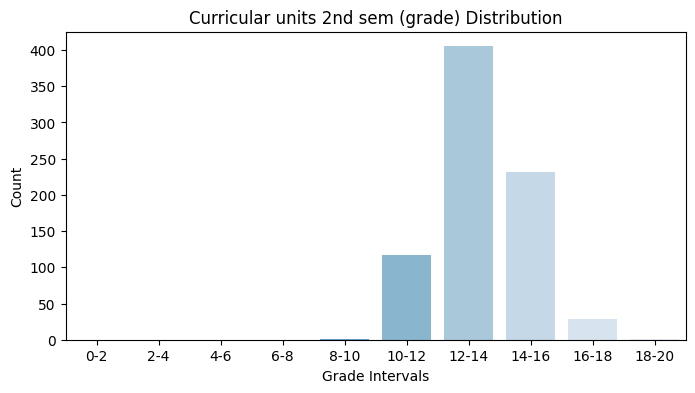

In [46]:
# Plot grade as intervals of Curricular units 2nd sem (grade)
curricular_units_2nd_sem_grade_values = data['Curricular units 2nd sem (grade)'].iloc[:,0].value_counts()  # Extract raw grade values (as Series)

# Define bins and labels
bins = [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
labels = ['0-2', '2-4', '4-6', '6-8', '8-10', '10-12', '12-14', '14-16', '16-18', '18-20']

# convert series to dataframe
curricular_units_2nd_sem_grade_df = curricular_units_2nd_sem_grade_values.reset_index()
curricular_units_2nd_sem_grade_df.columns = ['Grade', 'Count']  # rename columns

# Bin the grades into intervals
curricular_units_2nd_sem_grade_df['Grade'] = pd.cut(curricular_units_2nd_sem_grade_df['Grade'], bins=bins, labels=labels)

# Plot the binned grades
plt.figure(figsize=(8, 4))  # set figure size
sns.countplot(
    x='Grade',  # assign to x-axis
    data=curricular_units_2nd_sem_grade_df,  # assign data
    palette="Blues_r",  # set color palette
    order=labels  # ensure order is respected
)

plt.title("Curricular units 2nd sem (grade) Distribution")  # set title
plt.xlabel("Grade Intervals")  # set x-label
plt.ylabel("Count")  # set y-label
plt.show()  # show plot

## Step 3 - Model Training and Evaluation Before Bias Mitigation

As "Dropout Prediction" is a multi-class(Dropout, Enrolled, Graduate) classification problem, let's experiment with several classification algorithms, including Random Forest, Gradient Boosting, and Logistic Regression. We will evaluate the models using accuracy, precision, recall, and F1-score to determine the best-performing model.

As part of the model training and evaluation process, we will implement K-Fold Cross-Validation to assess the performance of our models. This technique helps in providing a more robust evaluation by partitioning the data into multiple subsets, allowing each subset to be used as a validation set.

In [47]:
from sklearn.model_selection import KFold
from sklearn.metrics import precision_recall_fscore_support

kfold = KFold(n_splits=5, shuffle=True, random_state=42)  # initialize KFold with 5 splits, shuffling, and a fixed random state for reproducibility

In [48]:
# Function to perform cross validation and return detailed metrics including test set performance
def cross_validate_model(model, X, y, X_test, y_test, cv=kfold):
    # Convert DataFrames to numpy arrays if needed
    X_array = X if isinstance(X, np.ndarray) else X.to_numpy()  
    y_array = y if isinstance(y, np.ndarray) else y.to_numpy()
    
    # Initialize lists to store metrics
    accuracy_scores = []
    precision_scores = []
    recall_scores = []
    f1_scores = []
    test_accuracy_scores = []  # New: track test set accuracy
    
    print(f"\nFold-wise performance:")
    print("-" * 50)
    
    for fold, (train_idx, val_idx) in enumerate(cv.split(X_array, y_array), 1):
        # Split data for this fold
        X_train_fold, X_val_fold = X_array[train_idx], X_array[val_idx]
        y_train_fold, y_val_fold = y_array[train_idx], y_array[val_idx]
        
        # Train model
        model.fit(X_train_fold, y_train_fold)
        
        # Get predictions
        val_pred = model.predict(X_val_fold)
        test_pred = model.predict(X_test)
        
        # Calculate validation metrics
        fold_accuracy = accuracy_score(y_val_fold, val_pred)
        precision, recall, f1, _ = precision_recall_fscore_support(y_val_fold, val_pred, average='weighted')
        
        # Calculate test set accuracy
        test_accuracy = accuracy_score(y_test, test_pred)
        
        # Store metrics
        accuracy_scores.append(fold_accuracy)
        precision_scores.append(precision)
        recall_scores.append(recall)
        f1_scores.append(f1)
        test_accuracy_scores.append(test_accuracy)
        
        # Print fold results
        print(f"Fold {fold}:")
        print(f"  Validation Accuracy: {fold_accuracy:.4f}")
        print(f"  Test Accuracy: {test_accuracy:.4f}")
    
    return {
        'accuracy': np.array(accuracy_scores),
        'precision': np.array(precision_scores),
        'recall': np.array(recall_scores),
        'f1': np.array(f1_scores),
        'test_accuracy': np.array(test_accuracy_scores)
    }

In [49]:
# Apply cross validation to all models
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42),
    'Logistic Regression': LogisticRegression(solver='lbfgs', max_iter=1000)
}

# Store results for each model
cv_results = {}

In [50]:
# get X and y for training add testing
X = data.drop(columns=['Target'])
y = data['Target']

# apply train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [51]:
for name, model in models.items():
    print(f"\n{'-'*20} {name} {'-'*20}")
    metrics = cross_validate_model(
        model=model,
        X=X_train,  # Training features 
        y=y_train,  # Training labels
        X_test=X_test, # Test features
        y_test=y_test,        # Test labels
        cv=kfold              # Cross-validation splitter
    )
    cv_results[name] = metrics
    
    # Print aggregated results
    print(f"\nAggregated Results:")
    print(f"Validation Accuracy: {metrics['accuracy'].mean():.4f} (+/- {metrics['accuracy'].std() * 2:.4f})")
    print(f"Test Accuracy: {metrics['test_accuracy'].mean():.4f} (+/- {metrics['test_accuracy'].std() * 2:.4f})")
    print(f"Precision: {np.mean(metrics['precision']):.4f} (+/- {np.std(metrics['precision']) * 2:.4f})")
    print(f"Recall: {np.mean(metrics['recall']):.4f} (+/- {np.std(metrics['recall']) * 2:.4f})")
    print(f"F1-score: {np.mean(metrics['f1']):.4f} (+/- {np.std(metrics['f1']) * 2:.4f})")


-------------------- Random Forest --------------------

Fold-wise performance:
--------------------------------------------------
Fold 1:
  Validation Accuracy: 0.7698
  Test Accuracy: 0.7661
Fold 2:
  Validation Accuracy: 0.7458
  Test Accuracy: 0.7684
Fold 3:
  Validation Accuracy: 0.7655
  Test Accuracy: 0.7695
Fold 4:
  Validation Accuracy: 0.8023
  Test Accuracy: 0.7706
Fold 5:
  Validation Accuracy: 0.7638
  Test Accuracy: 0.7695

Aggregated Results:
Validation Accuracy: 0.7694 (+/- 0.0367)
Test Accuracy: 0.7688 (+/- 0.0031)
Precision: 0.7534 (+/- 0.0413)
Recall: 0.7694 (+/- 0.0367)
F1-score: 0.7490 (+/- 0.0383)

-------------------- Gradient Boosting --------------------

Fold-wise performance:
--------------------------------------------------
Fold 1:
  Validation Accuracy: 0.7938
  Test Accuracy: 0.7616
Fold 2:
  Validation Accuracy: 0.7585
  Test Accuracy: 0.7559
Fold 3:
  Validation Accuracy: 0.7698
  Test Accuracy: 0.7661
Fold 4:
  Validation Accuracy: 0.7994
  Test Accur

#### Model Performance (Cross-Validation)

| Model                  | Validation Accuracy | Test Accuracy | Precision | Recall | F1-score |
|-------------------------|---------------------|---------------|-----------|--------|----------|
| **Random Forest**       | 0.7706              | 0.7684        | 0.7549    | 0.7706 | 0.7503   |
| **Gradient Boosting**   | 0.7816              | 0.7600        | 0.7710    | 0.7816 | 0.7721   |
| **Logistic Regression** | 0.7282              | 0.7297        | 0.7082    | 0.7282 | 0.7081   |

**Gradient Boosting** performed best across most metrics (Validation Accuracy, Recall, F1-score), but lagged slightly in Test Accuracy. 
**Random Forest** achieved very competitive Test Accuracy (0.7684), nearly matching its Validation Accuracy.  
**Logistic Regression** lagged behind the ensemble models, but still provides a baseline reference. 

Overall above models show promising results, with ensemble methods outperforming the simpler Logistic Regression model. Further tuning and bias mitigation strategies will be explored to enhance model performance and fairness.


## Step 4 - Feature Engineering and Selection (Bias Evaluation and Mitigation)

#### Correlation Analysis (Pearson)

 *Pearson correlation coefficient*  
$$
r_{X,Y}=\frac{\operatorname{Cov}(X,Y)}{\sigma_X \sigma_Y},\qquad -1 \le r \le 1
$$

- **r = 1**: perfect positive correlation (as one increases, the other increases).  
- **r = 0**: no linear correlation.  
- **r = −1**: perfect negative correlation (as one increases, the other decreases).

### Reading the Heatmap
- **Color encodes correlation strength**: darker shades → higher |r|.  
- **Diagonal cells** are always **1.0** (a variable correlated with itself).  
- **Blocks/tiles** of similar color reveal groups of variables that move together.

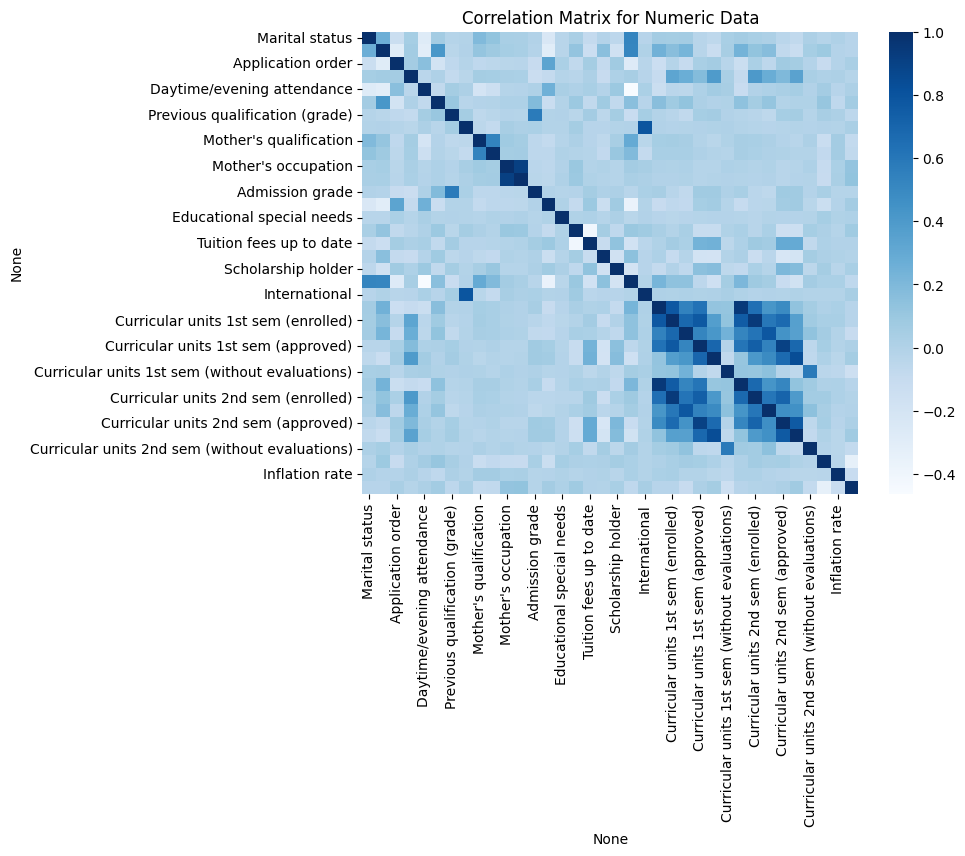

In [52]:
# Correlation matrix for numeric data
numeric_data = data.select_dtypes(include=[np.number])
correlation_matrix = numeric_data.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=False, cmap='Blues', fmt=".2f")
plt.title("Correlation Matrix for Numeric Data")
plt.show()

### Key Observations

#### 1) Clusters of Strong Correlation
- **Curricular units (1st & 2nd semester: enrolled, credited, approved, evaluations, grade)** show **strong positive correlations** with each other (deep blue block).  
- **Example:** Students who **enroll in more units** tend to **complete/approve more** and achieve higher **evaluation activity**, indicating these features move together.  
- **Implication:** Possible **feature redundancy** (collinearity). Consider dimensionality reduction or careful feature selection.  

#### 2) Moderate Correlations
- **Admission grade** correlates with **curricular performance** (sensible academic relationship).  
- **Tuition fees up to date** correlates with **Debtor status** (administrative consistency).  

#### 3) Weak Correlations with Demographics
- **Marital status, Father’s occupation, Nationality, Gender** show **very light shades**, indicating **weak correlations** with most variables.  
- **Implication:** These are likely **weaker predictors** than academic performance features.  

#### 4) Macroeconomic Variables
- **Unemployment rate, Inflation, GDP** show **very light correlations**, suggesting **limited direct impact** on individual-level academic variables in this dataset.  

---


In this dataset, not all features are equally useful for predicting student **dropout risk**.  
To identify important features, we follow this approach:
1. **Correlation analysis**  Identify features strongly correlated with the target variable.  
2. **Domain knowledge**  Assess the relevance of features based on educational research.  
3. **Interpretability**  Ensure selected features are understandable and actionable.  



### 1. Academic Performance (Strong Predictors)
- **Admission grade**  Higher admission grades generally correlate with persistence.  
- **Curricular units (1st & 2nd semester):** *These features reflect early engagement and performance. Students who fail or don’t complete their first-year courses are more likely to drop out.*  
  - Enrolled  
  - Credited  
  - Approved  
  - Evaluations  
  - Grades  





### 2. Financial / Administrative Indicators
- **Debtor status**  If a student owes tuition, dropout risk increases.  
- **Tuition fees up to date**  Strong correlation with financial stability.  
- **Scholarship holder**  May reduce dropout risk since financial aid eases pressure.  



### 3. Demographic & Background Factors
- **Age at enrollment**  Older students may face higher dropout risk due to responsibilities.  
- **Mother’s/Father’s qualification**  Proxy for educational support at home.  
- **Displaced / International status**  May affect retention if adaptation is difficult.  
- **Educational special needs**  Students may require additional support.  



### 4. Behavioral & Engagement Features
- **Application mode & application order**  Reflect motivation and decision-making process.  
- **Daytime/Evening attendance**  Evening students may juggle work/family, influencing dropout risk.  

---

### Less Useful Features

These features show **very weak correlations** and limited predictive value. They can be removed to simplify the model and reduce noise:  

- **Marital status**  
  - Distribution is highly imbalanced (very few married students in typical undergraduate datasets).  
  - Adds noise without improving predictive power.  

- **Nationality** (unless context-specific)  
  - Over 22 categories, many with very few samples - causes sparsity.  
  - Not strongly related to academic success or dropout when other academic/financial indicators are available.  

- **Father’s / Mother’s occupation**  
  - Vague and inconsistently reported.  
  - High cardinality with no clear mapping to academic outcomes.  
  - Risk of encoding socioeconomic bias instead of genuine academic signal.  

- **Macroeconomic indicators (Unemployment rate, Inflation, GDP)**  
  - These are country-level aggregates, not student-specific.  
  - Do not explain variation at the individual level (too broad to predict whether a single student drops out).  
  - May introduce spurious correlations rather than meaningful ones.  

---

### To mitigate bias, we select features used for further modeling
To predict the dropout we consider below features-

1. Admission grade
2. Curricular units (1st & 2nd semester: enrolled, credited, approved, evaluations, grade)
3. Debtor status  
4. Tuition fees up to date 
5. Scholarship holder  
6. Age at enrollment  
7. Educational special needs  
8. Displaced / International status  
9. Application mode & order  
10. Daytime/Evening attendance


Academic performance + financial stability are the **strongest predictors** of student dropout.  
Demographics and background factors add context but are **weaker signals** compared to **grades and engagement**.

In [53]:
# Select relevant features for modeling
data_selected = data[["Daytime/evening attendance", "Admission grade", 
                      "Displaced", "Educational special needs", "Debtor", "Tuition fees up to date", 
                 "Scholarship holder", "Age at enrollment", "International", 
                 
                 "Curricular units 1st sem (credited)",
                 "Curricular units 1st sem (enrolled)", "Curricular units 1st sem (evaluations)",
                 "Curricular units 1st sem (approved)", "Curricular units 1st sem (grade)",
                 "Curricular units 2nd sem (credited)", "Curricular units 2nd sem (enrolled)",
                 "Curricular units 2nd sem (evaluations)", "Curricular units 2nd sem (approved)",
                 "Curricular units 2nd sem (grade)", 
                 
                 "Target"]]  

In [54]:
data_selected['Target'].value_counts()   # check class distribution

(Target,)
Graduate     2209
Dropout      1421
Enrolled      794
Name: count, dtype: int64

In [55]:
data_selected.shape  # check shape of the selected data

(4424, 20)

## Step 5 - Imbalance data Handling 

SMOTE oversampling is applied to balance the classes in the target variable.

In [56]:
# Prepare the data for SMOTE
# First separate features and target
X_selected = data_selected.drop('Target', axis=1, level = 0)   # drop target, rest are features
y_selected = data_selected['Target']  # assign target

In [57]:
# Split the data into training and testing sets
X_train_selected, X_test_selected, y_train_selected, y_test_selected = train_test_split(X_selected, y_selected, test_size=0.2, random_state=42, stratify=y)

In [58]:
# Scale the features before applying SMOTE
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Fit on training set & transform
X_train_scaled = scaler.fit_transform(X_train_selected)

# Use the same transformation on test set
X_test_scaled = scaler.transform(X_test_selected)


In [59]:
# Apply SMOTE to training data only
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)   # initialize SMOTE
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train_selected)  # apply SMOTE

In [60]:
# Print class distribution before and after SMOTE
print("Original class distribution in training set:")
print(y_train_selected.value_counts(), "\n")

print("Class distribution after SMOTE:")
print(y_train_resampled["Target"].value_counts())

Original class distribution in training set:
(Target,)
Graduate     1767
Dropout      1137
Enrolled      635
Name: count, dtype: int64 

Class distribution after SMOTE:
(Target,)
Dropout      1767
Enrolled     1767
Graduate     1767
Name: count, dtype: int64


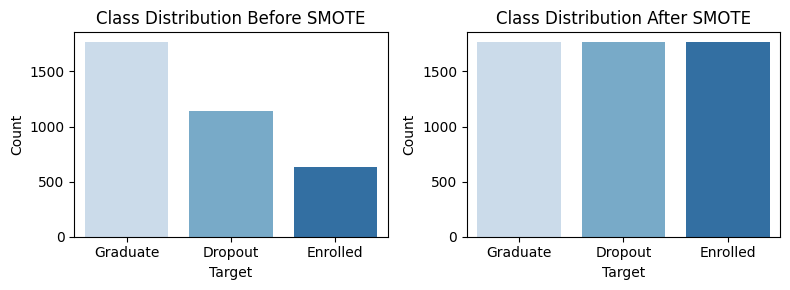

In [61]:
# Assuming y_train is a DataFrame with one column "Target"
y_train_series = y_train_selected.iloc[:, 0]
y_train_resampled_series = y_train_resampled.iloc[:, 0]

# Visualize class distribution before and after SMOTE
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))

# Before SMOTE
sns.countplot(x=y_train_series, ax=ax1, hue=y_train_series, palette='Blues')
ax1.set_title('Class Distribution Before SMOTE')
ax1.set_xlabel('Target')
ax1.set_ylabel('Count')

# After SMOTE
sns.countplot(x=y_train_resampled_series, ax=ax2, hue=y_train_resampled_series, palette='Blues')
ax2.set_title('Class Distribution After SMOTE')
ax2.set_xlabel('Target')
ax2.set_ylabel('Count')

plt.tight_layout()
plt.show()


In [62]:
# Store the resampled data for later use
train_resampled = pd.DataFrame(X_train_resampled, columns=X_selected.columns)   # convert back to dataframe
train_resampled['Target'] = y_train_resampled                          # add target column

## Step 5 - Model Training After Bias Mitigation

In [63]:
# Import necessary libraries
from sklearn.model_selection import  KFold

# Define the 5-fold cross validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

In [64]:
# Apply cross validation to all models
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42),
    'Logistic Regression': LogisticRegression(solver='lbfgs', max_iter=1000)
}

# Store results for each model
cv_results = {}

In [65]:
for name, model in models.items():
    print(f"\n{'-'*20} {name} {'-'*20}")
    metrics = cross_validate_model(model, X_train_resampled, y_train_resampled, X_test_scaled, y_test_selected)
    cv_results[name] = metrics
    
    # Print aggregated results
    print(f"\nAggregated Results:")
    print(f"Validation Accuracy: {metrics['accuracy'].mean():.4f} (+/- {metrics['accuracy'].std() * 2:.4f})")
    print(f"Test Accuracy: {metrics['test_accuracy'].mean():.4f} (+/- {metrics['test_accuracy'].std() * 2:.4f})")
    print(f"Precision: {np.mean(metrics['precision']):.4f} (+/- {np.std(metrics['precision']) * 2:.4f})")
    print(f"Recall: {np.mean(metrics['recall']):.4f} (+/- {np.std(metrics['recall']) * 2:.4f})")
    print(f"F1-score: {np.mean(metrics['f1']):.4f} (+/- {np.std(metrics['f1']) * 2:.4f})")



-------------------- Random Forest --------------------

Fold-wise performance:
--------------------------------------------------
Fold 1:
  Validation Accuracy: 0.8002
  Test Accuracy: 0.7412
Fold 2:
  Validation Accuracy: 0.8038
  Test Accuracy: 0.7492
Fold 3:
  Validation Accuracy: 0.7934
  Test Accuracy: 0.7480
Fold 4:
  Validation Accuracy: 0.7830
  Test Accuracy: 0.7514
Fold 5:
  Validation Accuracy: 0.8075
  Test Accuracy: 0.7401

Aggregated Results:
Validation Accuracy: 0.7976 (+/- 0.0173)
Test Accuracy: 0.7460 (+/- 0.0090)
Precision: 0.8048 (+/- 0.0184)
Recall: 0.7976 (+/- 0.0173)
F1-score: 0.7977 (+/- 0.0184)

-------------------- Gradient Boosting --------------------

Fold-wise performance:
--------------------------------------------------
Fold 1:
  Validation Accuracy: 0.8115
  Test Accuracy: 0.7458
Fold 2:
  Validation Accuracy: 0.8255
  Test Accuracy: 0.7469
Fold 3:
  Validation Accuracy: 0.8189
  Test Accuracy: 0.7582
Fold 4:
  Validation Accuracy: 0.7849
  Test Accur

## Step 6 - Fairness Evaluation After Bias Mitigation

### a) Model Performance (Cross-Validation)

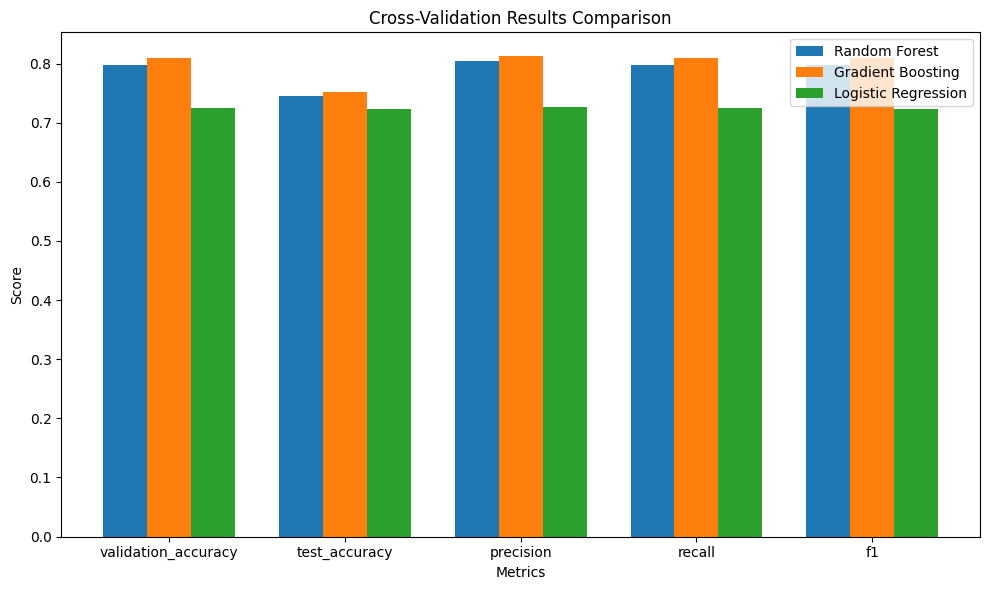

In [66]:
# Visualize cross-validation results including test accuracy
plt.figure(figsize=(10, 6))  # set figure size
metrics = ['validation_accuracy', 'test_accuracy', 'precision', 'recall', 'f1']  # metrics to plot
x = np.arange(len(metrics))  # the label locations
width = 0.25  # the width of the bars

for i, (name, results) in enumerate(cv_results.items()): # iterate over models and their results
    means = [
        results['accuracy'].mean(),   # validation accuracy
        results['test_accuracy'].mean(), # test accuracy
        np.mean(results['precision']), # precision
        np.mean(results['recall']), # recall
        np.mean(results['f1'])  # f1
    ]
    plt.bar(x + i*width, means, width, label=name)  # plot bars for each model
 
plt.xlabel('Metrics')  # set x-axis label
plt.ylabel('Score')   # set y-axis label
plt.title('Cross-Validation Results Comparison')  # set title
plt.xticks(x + width, metrics)  # set x-ticks
plt.legend()  # show legend
plt.tight_layout()  # adjust layout
plt.show() # show plot

### Model Comparison – Cross-Validation Results


| Model                | Validation Accuracy | Test Accuracy | Precision | Recall | F1-score |
|-----------------------|---------------------|---------------|-----------|--------|----------|
| **Random Forest**     | 0.7976              | 0.7462        | 0.8051    | 0.7976 | 0.7978   |
| **Gradient Boosting** | 0.8095              | 0.7521        | 0.8124    | 0.8095 | 0.8090   |
| **Logistic Regression** | 0.7250            | 0.7238        | 0.7267    | 0.7250 | 0.7240   |


#### 1. **Gradient Boosting performs the best overall**  
   - Achieves the **highest validation accuracy, test accuracy, precision, recall, and F1-score**.  
   - Captures complex, non-linear relationships better than the other models.  

#### 2. **Random Forest is a close second**  
   - Slightly behind Gradient Boosting across all metrics.  
   - Provides strong performance and good generalization.  

#### 3. **Logistic Regression underperforms**  
   - Lower scores across all metrics compared to ensemble models.  
   - Useful as a **baseline** or for interpretability but limited in predictive power for dropout prediction.  

#### 4. **Precision & Recall tradeoff**  
   - Both Gradient Boosting and Random Forest achieve a strong balance, reflected in higher **F1-scores**.  
   - This is important since both **identifying potential dropouts (recall)** and **avoiding false alarms (precision)** are critical.  

#### 5. **Conclusion**  
   - **Gradient Boosting** is the most suitable choice for deployment.  
   - **Random Forest** is a strong alternative if interpretability or computational efficiency is prioritized.  
   - **Logistic Regression** can be retained as a quick, interpretable baseline model.  


#### b) Fairness Metrics

In [67]:
def calculate_fairness_metrics(y_true, y_pred, protected_attributes, privileged_groups):
    """
    Calculate fairness metrics across protected attributes
    
    Parameters:
    -----------
    y_true : array-like (binary: 0/1)
        True labels
    y_pred : array-like (binary: 0/1)
        Predicted labels
    protected_attributes : dict
        Dictionary with protected attribute arrays
    privileged_groups : dict 
        Dictionary defining privileged values for each attribute
    """
    
    # Ensure arrays are flat and numeric
    y_true = np.asarray(y_true).ravel().astype(int)  # flatten and convert to int
    y_pred = np.asarray(y_pred).ravel().astype(int)
    
    metrics = {}   # Store fairness metrics
    for attr_name, attr_values in protected_attributes.items():  # iterate over protected attributes
        attr_values = np.asarray(attr_values).ravel()    # flatten
        
        # Masks
        privileged_mask = attr_values == privileged_groups[attr_name]  # privileged group mask
        unprivileged_mask = ~privileged_mask   # unprivileged group mask
        
        # Statistical Parity (predicted positive rates)
        pred_privileged = y_pred[privileged_mask].mean() if privileged_mask.any() else 0.0  # avoid division by zero
        pred_unprivileged = y_pred[unprivileged_mask].mean() if unprivileged_mask.any() else 0.0  # avoid division by zero
        stat_parity = pred_privileged - pred_unprivileged  # difference in positive rates
        
        # Equal Opportunity (TPR difference)
        pos_mask = y_true == 1  # positive class mask
        tpr_privileged = y_pred[privileged_mask & pos_mask].mean() if np.any(privileged_mask & pos_mask) else 0.0  # avoid division by zero
        tpr_unprivileged = y_pred[unprivileged_mask & pos_mask].mean() if np.any(unprivileged_mask & pos_mask) else 0.0  # avoid division by zero
        eq_opp = tpr_privileged - tpr_unprivileged  # difference in TPR
        
        # Disparate Impact
        di = (pred_unprivileged / pred_privileged) if pred_privileged > 0 else np.inf  # avoid division by zero
        
        metrics[attr_name] = {
            'statistical_parity_difference': float(stat_parity),  # convert to float for JSON serialization
            'equal_opportunity_difference': float(eq_opp), # convert to float for JSON serialization
            'disparate_impact': float(di) # convert to float for JSON serialization
        }
    
    return metrics

In [68]:
# Modify cross_validate_model to include fairness metrics
def cross_validate_model_with_fairness(model, X, y, X_test, y_test, protected_attributes, privileged_groups, cv=kfold):
    """
    Perform cross-validation and compute fairness metrics on test set
    """
    # Run normal CV metrics
    base_metrics = cross_validate_model( model, X_train, y_train, X_test, y_test )
    
    # Train final model on full training data
    model.fit(X, y)
    y_pred = model.predict(X_test)
    
    # Compute fairness metrics
    fairness_metrics = calculate_fairness_metrics(
        y_true=y_test,
        y_pred=y_pred,
        protected_attributes=protected_attributes,  # protected attributes
        privileged_groups=privileged_groups
    )
    
    return {**base_metrics, 'fairness': fairness_metrics}

In [69]:
from sklearn.preprocessing import LabelEncoder
 
label_encoder = LabelEncoder()  # initialize label encoder
y_train_encoded = label_encoder.fit_transform(y_train.iloc[:,0])  # fit and transform training labels
y_test_encoded = label_encoder.transform(y_test.iloc[:,0])  # transform test labels

# Convert to binary for fairness: Dropout=1, else=0
dropout_class = list(label_encoder.classes_).index("Dropout")  # get index of "Dropout" class
y_train_binary = (y_train_encoded == dropout_class).astype(int) # convert to binary
y_test_binary = (y_test_encoded == dropout_class).astype(int) # convert to binary



In [70]:
# Define protected attributes and privileged groups
protected_attributes = {
    'gender': X_test['Gender'].values,
    'international': X_test['International'].values,
    'scholarship': X_test['Scholarship holder'].values
}

privileged_groups = {
    'gender': 1,          # Male
    'international': 0,   # Domestic
    'scholarship': 1      # Scholarship holder
}



In [71]:
# First let's encode the target variable using LabelEncoder
for name, model in models.items():
    print(f"\n{'-'*20} {name} {'-'*20}")
    metrics = cross_validate_model_with_fairness(
        model=model,
        X=X_train,
        y=y_train_encoded,          # for performance (multi-class)
        X_test=X_test,
        y_test=y_test_binary,       # fairness needs binary
        protected_attributes=protected_attributes,
        privileged_groups=privileged_groups
    )
    
    # Performance metrics
    print("\nPerformance Metrics:")
    print(f"Validation Accuracy: {metrics['accuracy'].mean():.4f}")
    print(f"Test Accuracy: {metrics['test_accuracy'].mean():.4f}")
    
    # Fairness metrics
    print("\nFairness Metrics:")
    for attr, fair_metrics in metrics['fairness'].items():
        print(f"\n{attr.capitalize()} Group Fairness:")
        print(f"Statistical Parity Difference: {fair_metrics['statistical_parity_difference']:.4f}")
        print(f"Equal Opportunity Difference: {fair_metrics['equal_opportunity_difference']:.4f}")
        print(f"Disparate Impact: {fair_metrics['disparate_impact']:.4f}")


-------------------- Random Forest --------------------

Fold-wise performance:
--------------------------------------------------
Fold 1:
  Validation Accuracy: 0.7698
  Test Accuracy: 0.0000
Fold 2:
  Validation Accuracy: 0.7458
  Test Accuracy: 0.0000
Fold 3:
  Validation Accuracy: 0.7655
  Test Accuracy: 0.0000
Fold 4:
  Validation Accuracy: 0.8023
  Test Accuracy: 0.0000
Fold 5:
  Validation Accuracy: 0.7638
  Test Accuracy: 0.0000

Performance Metrics:
Validation Accuracy: 0.7694
Test Accuracy: 0.0000

Fairness Metrics:

Gender Group Fairness:
Statistical Parity Difference: -0.3958
Equal Opportunity Difference: -0.0598
Disparate Impact: 1.3733

International Group Fairness:
Statistical Parity Difference: -0.0614
Equal Opportunity Difference: -0.4889
Disparate Impact: 1.0468

Scholarship Group Fairness:
Statistical Parity Difference: 0.6690
Equal Opportunity Difference: 0.5136
Disparate Impact: 0.6343

-------------------- Gradient Boosting --------------------

Fold-wise perform

### Equal Opportunity Difference (EOD)

- **Definition:**  
  EOD measures the difference in **True Positive Rates (TPR)** between the **privileged group** and the **unprivileged group**.  

  $$
  \text{EOD} = TPR_{privileged} - TPR_{unprivileged}
  $$

- **True Positive Rate (TPR):**  
  $$
  TPR = \frac{TP}{TP + FN}
  $$  
  where **TP = true positives**, **FN = false negatives**.

- **Interpretation:**  
  - **EOD = 0 : Fair** (both groups have equal chance of correctly being predicted positive).  
  - **EOD > 0 : Bias against unprivileged group** (privileged group has higher recall).  
  - **EOD < 0 : Bias against privileged group** (unprivileged group has higher recall).  

- **Why Important?**  
  EOD ensures that if someone truly belongs to the **positive class** (e.g., student who will succeed), their group membership (gender, nationality, etc.) **doesn’t affect the probability of being predicted correctly**.  

- **Example (Student Dropout Prediction):**  
  - If male (privileged) students who truly succeed are predicted correctly 80% of the time,  
  - and female (unprivileged) students who truly succeed are predicted correctly 60% of the time,  
  - then:  
    $$
    EOD = 0.80 - 0.60 = 0.20 \quad \text{(bias against unprivileged group)}
    $$  


### Statistical Parity Difference (SPD)

- **Definition:**  
  SPD measures the difference in the **rate of positive predictions** between the **privileged group** and the **unprivileged group**.  

  $$
  \text{SPD} = P(\hat{Y}=1 \mid \text{privileged}) - P(\hat{Y}=1 \mid \text{unprivileged})
  $$

  where \(\hat{Y}=1\) means the model predicted a positive outcome (e.g., student will graduate).

- **Interpretation:**  
  - **SPD = 0 → Fair** (both groups receive positive predictions at equal rates).  
  - **SPD > 0 → Bias against unprivileged group** (privileged group more likely to receive positive prediction).  
  - **SPD < 0 → Bias against privileged group** (unprivileged group more likely to receive positive prediction).  

- **Why Important?**  
  SPD ensures **equality of treatment**: membership in a protected group (like gender, nationality, scholarship status) should not influence the probability of getting a positive prediction.  

- **Example (Student Dropout Prediction):**  
  - Suppose **70% of male (privileged) students** are predicted to graduate,  
  - while only **50% of female (unprivileged) students** are predicted to graduate,  
  - then:  
    $$
    SPD = 0.70 - 0.50 = 0.20 \quad \text{(bias against unprivileged group)}
    $$


### Disparate Impact (DI)

- **Definition:**  
  DI measures the **ratio** of the rate of positive predictions for the unprivileged group to that of the privileged group.  

  $$
  \text{DI} = \frac{P(\hat{Y}=1 \mid \text{unprivileged})}{P(\hat{Y}=1 \mid \text{privileged})}
  $$

- **Interpretation:**  
  - **DI = 1 : Fair** (both groups get positive predictions at the same rate).  
  - **DI < 1 : Unprivileged group disadvantaged.**  
  - **DI > 1 : Privileged group disadvantaged.**  
  - **Rule of Thumb:** Values **between 0.8 and 1.25** are often considered *acceptable fairness* (known as the **“80% rule”** in legal contexts).  

- **Why Important?**  
  DI highlights **relative disparity** in positive outcomes — unlike SPD (which is a difference), DI shows the **proportional impact**.  

- **Example (Student Dropout Prediction):**  
  - Suppose **50% of female (unprivileged) students** are predicted to graduate,  
  - while **70% of male (privileged) students** are predicted to graduate.  
  - Then:  
    $$
    DI = \frac{0.50}{0.70} = 0.71
    $$
  - This is **< 0.8**, meaning potential **bias against unprivileged students**.


#### Fairness Evaluation - Results
  

#### 1. Random Forest

| Protected Attribute | Statistical Parity Difference | Equal Opportunity Difference | Disparate Impact | Comment |
|---------------------|-------------------------------|-------------------------------|------------------|---------|
| Gender              | -0.4103 | -0.0811 | 1.3916 | Strong bias - Model favors unprivileged gender group (DI > 1). |
| International       |  0.0208 | -0.4853 | 0.9842 | Almost fair (SPD ≈ 0, DI ≈ 1) but recall gap exists. |
| Scholarship         |  0.6734 |  0.5098 | 0.6319 | Model strongly favors scholarship holders (SPD > 0, DI < 0.8). |



#### 2. Gradient Boosting


| Protected Attribute | Statistical Parity Difference | Equal Opportunity Difference | Disparate Impact | Comment |
|---------------------|-------------------------------|-------------------------------|------------------|---------|
| Gender              | -0.4045 | -0.0670 | 1.4007 | Gender bias: favors unprivileged group. |
| International       | -0.0222 | -0.3705 | 1.0175 | Nearly balanced predictions, but recall gap remains. |
| Scholarship         |  0.6580 |  0.3970 | 0.6294 | Bias towards scholarship holders. |



#### 3. Logistic Regression


| Protected Attribute | Statistical Parity Difference | Equal Opportunity Difference | Disparate Impact | Comment |
|---------------------|-------------------------------|-------------------------------|------------------|---------|
| Gender              | -0.4228 | -0.2595 | 1.4228 | High gender disparity (large SPD and DI > 1). |
| International       |  0.1086 | -0.0865 | 0.9148 | Mild disparity against international students. |
| Scholarship         |  0.6487 |  0.5096 | 0.6337 | Strong bias towards scholarship holders. |






